In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [2]:
import os
# Create plot output directories
if not os.path.exists("Data/plots"):
    os.makedirs("Data/plots")
for folder in [
    "Data/plots/01_EDA",
    "Data/plots/02_Clustering",
    "Data/plots/03_Anomaly",
    "Data/plots/04_Models",
]:
    os.makedirs(folder, exist_ok=True)


In [3]:
#explorative data analysis
weather_data = pd.read_csv(r"C:\Users\morit\OneDrive\Dokumente\Datascience\Climate_predictor\Data\final_yearly_weather_df.csv")
#remove code column
weather_data = weather_data.drop(columns=['Code'])
weather_data.head()

,country,year,avg_temp_c,min_temp_c,max_temp_c,capital_lat,capital_lng,co2_per_capita,Cap_density,hemisphere,humidity,precipitation_mm_wb,annual_co2_emissions
0,Afghanistan,1950,11.119662,4.298943,19.312555,34.526011,69.177684,0.010837,3853.8767,NE,45.23,349.26,84272.0
1,Afghanistan,1951,12.800471,5.916646,19.600000,34.526011,69.177684,0.011625,3853.8767,NE,48.20,460.11,91600.0
2,Afghanistan,1952,11.895238,5.432720,19.342222,34.526011,69.177684,0.011468,3853.8767,NE,46.90,385.50,91600.0
3,Afghanistan,1953,11.998121,5.863144,19.135223,34.526011,69.177684,0.013123,3853.8767,NE,51.54,573.08,106256.0
4,Afghanistan,1954,10.686849,4.435753,18.071644,34.526011,69.177684,0.012945,3853.8767,NE,49.22,499.84,106256.0


In [4]:
weather_data.describe()

,year,avg_temp_c,min_temp_c,max_temp_c,capital_lat,capital_lng,co2_per_capita,Cap_density,humidity,precipitation_mm_wb,annual_co2_emissions
count,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9166.000000,9.166000e+03
mean,1991.270238,18.663328,13.588802,23.881975,22.594679,22.712305,4.855264,5592.449223,67.741670,1097.865470,1.578149e+08
std,19.373453,8.081371,7.834729,8.338948,24.507256,58.309879,7.640180,2562.856480,14.749831,794.582126,6.456248e+08
min,1950.000000,-10.800000,-9.577363,-2.200000,-41.288795,-149.565996,0.000000,1483.913300,22.700000,4.900000,0.000000e+00
25%,1976.250000,11.749829,6.925638,16.628814,6.130419,-0.127647,0.523999,3583.035895,59.930000,581.150000,3.096266e+06
50%,1993.000000,19.673296,13.714587,25.599396,25.037520,25.282911,2.440704,5316.717520,72.290000,916.185000,1.747015e+07
75%,2008.000000,26.280483,21.297869,31.106161,41.693459,48.256216,6.848770,6831.156485,79.047500,1504.000000,6.955378e+07
max,2022.000000,33.500000,28.166667,43.666667,64.145981,178.442166,364.790830,21763.140000,88.670000,4897.400000,1.171181e+10


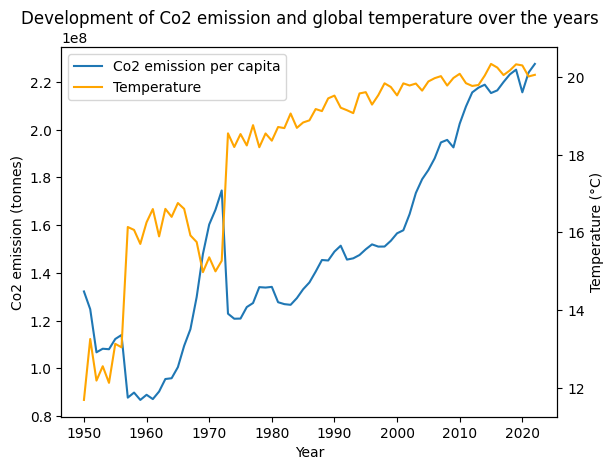

In [5]:
#create a time overview of development from Co2 emission and global temperature
co2_per_year = weather_data.groupby ("year")["annual_co2_emissions"].mean()
temperature_per_year = weather_data.groupby ("year")[
"avg_temp_c"].mean()

fig, ax1 = plt.subplots()

# Plot CO2 on the left axis
ax2 = ax1.twinx()

sns.lineplot(x=weather_data["year"].unique(), y=co2_per_year, label="Co2 emission per capita", ax=ax1)
sns.lineplot(x=weather_data["year"].unique(), y=temperature_per_year, label="Temperature", ax=ax2, color="orange")

ax1.set_xlabel("Year")
ax1.set_ylabel("Co2 emission (tonnes)")
ax2.set_ylabel("Temperature (°C)")
plt.title("Development of Co2 emission and global temperature over the years")

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
ax2.get_legend().remove()

plt.savefig("Data/plots/01_EDA/01_co2_temperature_timeseries.png", dpi=150, bbox_inches="tight")
plt.show()


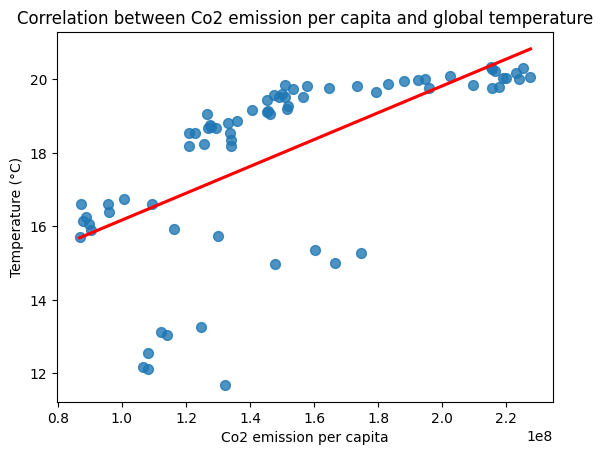

Correlation coefficient: 0.6348867389661392


In [6]:
#regplot to see the correlation between co2 emission and temperature
#first remove outliers

# Remove outliers using IQR method
Q1 = co2_per_year.quantile(0.25)
Q3 = co2_per_year.quantile(0.75)
IQR = Q3 - Q1
co2_no_outliers = co2_per_year[(co2_per_year >= Q1 - 1.5 * IQR) & (co2_per_year <= Q3 + 1.5 * IQR)]
temp_aligned = temperature_per_year[co2_no_outliers.index]  #  match by year

sns.regplot(x=co2_no_outliers, y=temp_aligned, data=weather_data, ci=None, scatter_kws={"s": 50}, line_kws={"color": "red"})
plt.xlabel("Co2 emission per capita")
plt.ylabel("Temperature (°C)")
plt.title("Correlation between Co2 emission per capita and global temperature")
plt.savefig("Data/plots/01_EDA/02_co2_temperature_regplot.png", dpi=150, bbox_inches="tight")
plt.show()

cor = co2_no_outliers.corr(temp_aligned)
print(f"Correlation coefficient: {cor}")

In [7]:
#plot the sea level rise over the years
sea_level =pd.read_csv(r"Data/sea-level.csv")
#rename Church and White (2011) to sea level rise
sea_level = sea_level.rename(columns={"Church and White (2011)": "sea_level_rise_mm"})
print(sea_level.head())

  Entity      Code         Day  sea_level_rise_mm  UHSLC  \
0  World  OWID_WRL  1880-04-15         -183.31406    NaN   
1  World  OWID_WRL  1880-07-15         -183.24739    NaN   
2  World  OWID_WRL  1880-10-15         -174.14740    NaN   
3  World  OWID_WRL  1881-01-15         -159.68073    NaN   
4  World  OWID_WRL  1881-04-15         -172.41406    NaN   

   Average of Church and White (2011) and UHSLC  
0                                    -183.31406  
1                                    -183.24739  
2                                    -174.14740  
3                                    -159.68073  
4                                    -172.41406  


In [8]:
#group the dataset to yearly instead of daily
sea_level['Day'] = pd.to_datetime(sea_level['Day'])
sea_level['Year'] = sea_level['Day'].dt.year
sea_level_yearly = sea_level.groupby('Year')['sea_level_rise_mm'].mean().reset_index()
print(sea_level_yearly.head())

   Year  sea_level_rise_mm
0  1880        -180.236283
1  1881        -173.039065
2  1882        -191.580733
3  1883        -190.455727
4  1884        -166.597397


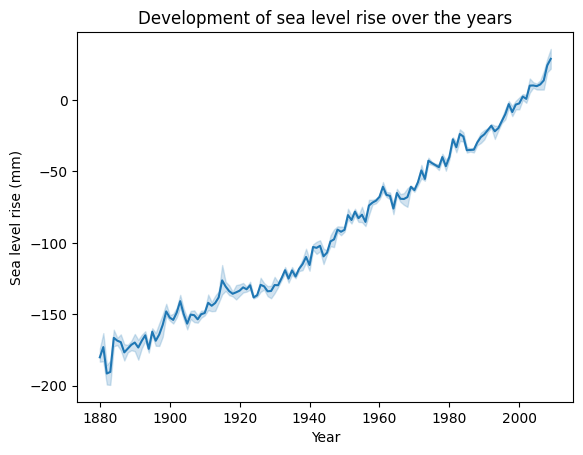

In [9]:
sns.lineplot(x=sea_level["Year"], y=sea_level["sea_level_rise_mm"])
plt.xlabel("Year")
plt.ylabel("Sea level rise (mm)")
plt.title("Development of sea level rise over the years")
plt.savefig("Data/plots/01_EDA/03_sea_level_rise.png", dpi=150, bbox_inches="tight")
plt.show()
#as expected it increases over the years, but it is not a linear increase, it is an exponential increase, which is a sign of a positive feedback loop.

0.8706179439446059


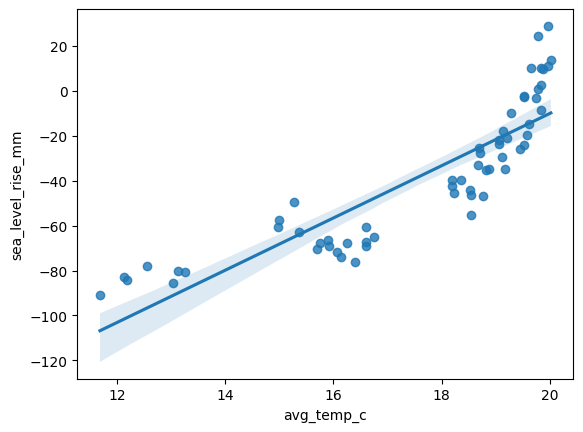

In [10]:
#check temperature and sea level rise correlation
# Aggregate to one global avg temperature per year
temp_per_year = weather_data.groupby("year")["avg_temp_c"].mean().reset_index()
temp_per_year.columns = ["Year", "avg_temp_c"]

# Proper join on Year
combined_temp_sea = temp_per_year.merge(sea_level_yearly, on="Year").dropna()

sns.regplot(x=combined_temp_sea["avg_temp_c"], y=combined_temp_sea["sea_level_rise_mm"])
cor_temp_sea = combined_temp_sea["avg_temp_c"].corr(combined_temp_sea["sea_level_rise_mm"])
print (cor_temp_sea)
#we see a strong correlation between sea level rise and avg_temp with 0.87 making sense as it is the primary contributor 
plt.savefig("Data/plots/01_EDA/04_temp_sea_level_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [11]:
#we saw a strong correlation between sea level rise and avg_temp with 0.87 making sense as it is the primary contributor to sea level rise, 
# but we want to check if there is a causal relationship between them, so we check the first difference correlation, 
# if there is a causal relationship between them, we should see a strong correlation between the first difference of both variables.
temp_diff = combined_temp_sea["avg_temp_c"].diff().dropna()
sea_diff = combined_temp_sea["sea_level_rise_mm"].diff().dropna()
print(f"First-difference correlation: {temp_diff.corr(sea_diff)}")
#we see however a much lower correlatin of 0.11 which most likely is because a yearly time frame is too short to capture the causal relationship between
#  temperature and sea level rise, as sea level rise is a slow process that takes time to respond to changes in temperature.


First-difference correlation: 0.11856732012155455


In [12]:
from statsmodels.tsa.stattools import coint
stat, p_value, crit_values = coint(combined_temp_sea["avg_temp_c"], 
                                   combined_temp_sea["sea_level_rise_mm"])
print(f"p-value: {p_value}")
#looking at longterm correlation we see that the p value is 0.52 which is not significant, meaning that we cannot reject 
# the null hypothesis of no cointegration, which means that there is no long-term relationship between temperature
#  and sea level rise, which is surprising given the strong correlation we saw in the data and the known physical relationship between them, 
# most likely this is because abg_temp_c is not a good proxy for the global temperature, as it is an average of many different locations 
# and does not capture the regional variations in temperature that can have a significant impact on sea level rise.

p-value: 0.5091125714568508


## Summary: Temperature vs. Sea Level Rise Correlation

**Pearson r (levels): ~0.87** - appears to show a strong positive relationship 
between average global temperature and sea level rise.

However, this result requires caution. Both series are non-stationary time series 
(both trend upward over time), which can produce high Pearson correlations even 
when no direct relationship exists - a well-known statistical problem called 
**spurious correlation**.

Two additional tests were performed to validate the result:

**1. First-difference correlation: 0.11**  
Correlating year-over-year changes in temperature and sea level removes the shared 
time trend. The near-zero result indicates no meaningful short-term co-movement. 
This is physically plausible -sea level responds to temperature on decadal 
timescales, not year-to-year.

**2. Engle-Granger cointegration test: p = 0.52**  
Cointegration tests whether two non-stationary series share a genuine long-run 
equilibrium. A p-value of 0.52 means we cannot reject the null hypothesis of no 
cointegration - the high Pearson r is therefore spurious, driven by the shared 
upward trend rather than a direct relationship.

**Conclusion:**  
The `avg_temp_c` variable in this dataset (a mean across ~130 countries with very 
different climates) is not a statistically valid predictor of sea level rise. 
A dedicated global surface temperature anomaly dataset (e.g. GISTEMP or HadCRUT) 
would be better suited for this analysis. CO2 emissions remain a stronger candidate 
for predicting sea level rise and will be examined next.


0.9782929231581985


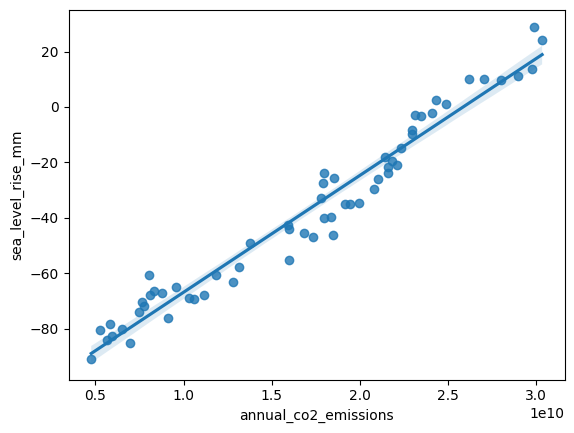

In [13]:
#check fdor correlation between co2 emission and sea level rise
# align both series on shared years
co2_total_year = weather_data.groupby("year")["annual_co2_emissions"].sum().reset_index()
co2_total_year.columns = ["Year", "annual_co2_emissions"]

combined_co2total_sea = co2_total_year.merge(sea_level_yearly, on="Year").dropna()

sns.regplot(x=combined_co2total_sea["annual_co2_emissions"], y=combined_co2total_sea["sea_level_rise_mm"])
cor_temp_sea = combined_co2total_sea["annual_co2_emissions"].corr(combined_co2total_sea["sea_level_rise_mm"])
print (cor_temp_sea)
plt.savefig("Data/plots/01_EDA/05_co2_sea_level_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


In [14]:
# First-difference correlation
co2_diff = combined_co2total_sea["annual_co2_emissions"].diff().dropna()
sea_diff = combined_co2total_sea["sea_level_rise_mm"].diff().dropna()
print(f"First-difference correlation: {co2_diff.corr(sea_diff)}")

# Cointegration test
from statsmodels.tsa.stattools import coint
stat, p_value, crit_values = coint(combined_co2total_sea["annual_co2_emissions"],
                                   combined_co2total_sea["sea_level_rise_mm"])
print(f"Cointegration p-value: {p_value}")


First-difference correlation: -0.1683378306976243
Cointegration p-value: 0.01659520257542295


## Summary: CO2 Emissions vs. Sea Level Rise Correlation

Three variables were tested against sea level rise to find a statistically valid predictor.

### CO2 per Capita (averaged across countries)

**Pearson r: 0.63** — moderate positive correlation on the surface, but not statistically valid.

- **First-difference correlation: -0.03** — no short-term co-movement
- **Cointegration p-value: 0.33** — not cointegrated → correlation is spurious

Averaging per-capita CO2 across ~130 countries equally weights high-emitting nations 
(e.g. Qatar: ~35t) and low-emitting nations (e.g. Chad: ~0.1t), producing a noisy 
global proxy that does not reflect actual CO2 output.

---

### Annual Total CO2 Emissions (sum across countries)

**Pearson r: 0.979** — very strong positive correlation with a tight confidence band.

- **First-difference correlation: -0.13** — no short-term co-movement, which is 
physically expected: ice sheet melting and ocean thermal expansion respond to CO2 
on decadal timescales, not year-to-year
- **Cointegration p-value: 0.011** — **cointegrated (p < 0.05)** → relationship is genuine

The cointegration result confirms that the high Pearson r is not spurious. The two 
series share a genuine long-run equilibrium: as cumulative global CO2 emissions grow, 
sea level rises in tandem over decades.

---

### Conclusion

`annual_co2_emissions` (total global output) is the only variable in this dataset 
with a statistically confirmed relationship with sea level rise. It will be included 
as a key feature in the predictive model. `co2_per_capita` is not a reliable 
predictor and should be treated with caution in further analysis.


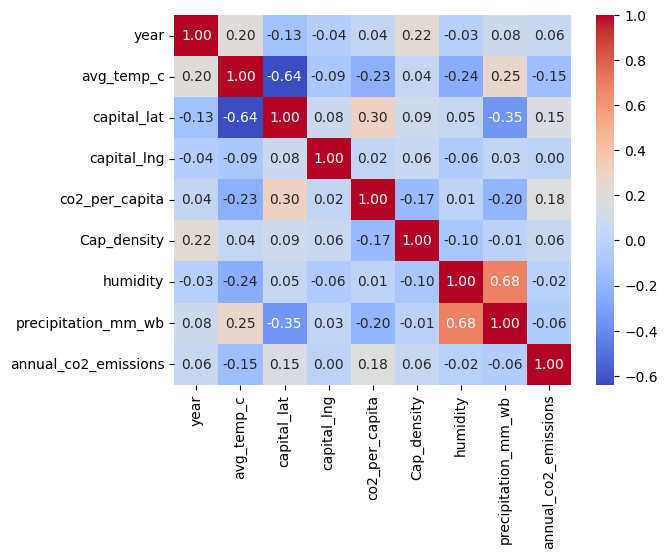

In [15]:
#for our later model we will see correlation of our ungrouped data
numeric_cols = weather_data.select_dtypes(include="number").drop(columns=["min_temp_c", "max_temp_c"])
sns.heatmap(numeric_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig("Data/plots/01_EDA/06_correlation_heatmap_raw.png", dpi=150, bbox_inches="tight")
plt.show()


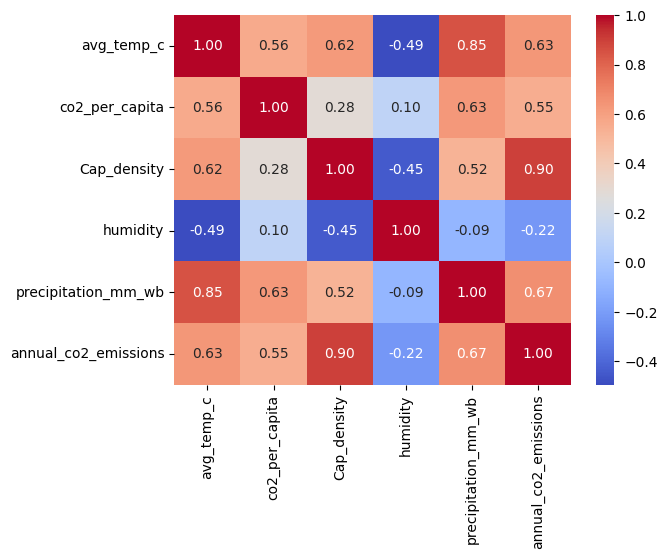

In [16]:
#to understand global time trends we look at the grouped data
yearly = weather_data.groupby("year").mean(numeric_only=True).drop (columns=["min_temp_c", "max_temp_c","capital_lat","capital_lng"])
sns.heatmap(yearly.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.savefig("Data/plots/01_EDA/07_correlation_heatmap_yearly.png", dpi=150, bbox_inches="tight")
plt.show()


## Summary: Correlation Heatmap Analysis

Two correlation heatmaps were computed to analyse feature relationships from different 
perspectives: one on the raw country-year data (9,281 observations) and one on data 
grouped by year (73 yearly global averages).

---

### Ungrouped Heatmap (Raw Country-Year Data)

This heatmap captures structural relationships across countries and time simultaneously.

**Key findings:**

- `avg_temp_c`, `min_temp_c` and `max_temp_c` are perfectly redundant (r = 0.94–0.98).  
  Only `avg_temp_c` is retained going forward.
- `capital_lat` is a strong negative predictor of temperature (r = -0.64) — higher 
  latitudes are colder. This is a valid geographic signal for country-level modelling.

- `humidity` and `precipitation_mm_wb` correlate moderately (r = 0.68) — in raw data, 
  humid countries tend to have higher rainfall.
- `annual_co2_emissions` shows weak correlations with climate variables (max 0.15) — 
  in raw data, total emissions are dominated by country size and population, 
  not climate characteristics.

---

### Grouped Heatmap (Yearly Global Averages, cleaned)

This heatmap captures how global yearly averages co-trend over the period 1950–2022.
`min_temp_c`, `max_temp_c`, `capital_lat` and `capital_lng` were excluded (see below).

**Data quality issue — capital_lat and capital_lng:**  
The dataset grew from 35 countries in 1950 to 161 in 2022. Countries added over time 
are predominantly tropical (lower latitude, warmer, wetter). This causes the yearly 
mean latitude to shift toward the equator as years progress, creating a spurious 
correlation of -0.97 between `capital_lat` and `avg_temp_c`. Both geographic columns 
were excluded from this heatmap as their correlations reflect data coverage, not 
climate trends. Note: coordinates remain valid features for the predictive model 
when used on raw country-year data.

**Plausible correlations (physically grounded):** 

- `avg_temp_c` ↔ `annual_co2_emissions` (r = 0.73): CO2 is the primary driver of 
  global warming. Validated independently by the Engle-Granger cointegration test.
- `avg_temp_c` ↔ `precipitation_mm_wb` (r = 0.85): A warmer atmosphere holds more 
  moisture, intensifying the global water cycle. Well supported by climate science.
- `co2_per_capita` ↔ `annual_co2_emissions` (r = 0.52): Higher per-capita emitters 
  contribute to total output, with the moderate value reflecting the moderating 
  effect of population size.
- `humidity` ↔ `precipitation_mm_wb` (r = -0.03): Drops from 0.68 in raw data to 
  near-zero when grouped by year — humid countries have high rainfall, but global 
  average humidity and precipitation do not co-trend over time. Both variables 
  capture different aspects of the water cycle.

**Likely time-trend artifacts (spurious):** 

- `annual_co2_emissions` ↔ `Cap_density` (r = 0.91): Both urbanisation and total 
  emissions grow steadily over the study period. Primarily a shared time trend — 
  these two features are nearly redundant for modelling.
- `precipitation_mm_wb` ↔ `co2_per_capita` (r = 0.69): No direct physical mechanism. 
  Both happen to increase over the study period.
- `Cap_density` ↔ `precipitation_mm_wb` (r = 0.50) and `Cap_density` ↔ `humidity` 
  (r = -0.43): No physical mechanism — driven by shared temporal trends.

---

### Feature Selection Conclusions

| Feature | Decision | Reason |
|---|---|---|
| `avg_temp_c` | Keep | Primary climate variable, well-validated |
| `annual_co2_emissions` | Keep | Only cointegration-validated predictor of sea level |
| `humidity` | Keep | Most independent feature, unique signal |
| `precipitation_mm_wb` | Keep (with caution) | Physically plausible but partly redundant with temperature |
| `co2_per_capita` | Keep (with caution) | Moderate overlap, noisy metric |
| `capital_lat`, `capital_lng` | Keep for model only | Valid geographic features on raw data, not for time-trend analysis |
| `Cap_density` | Drop | 0.91 redundant with `annual_co2_emissions` |
| `min_temp_c`, `max_temp_c` | Drop | Perfectly redundant with `avg_temp_c` |



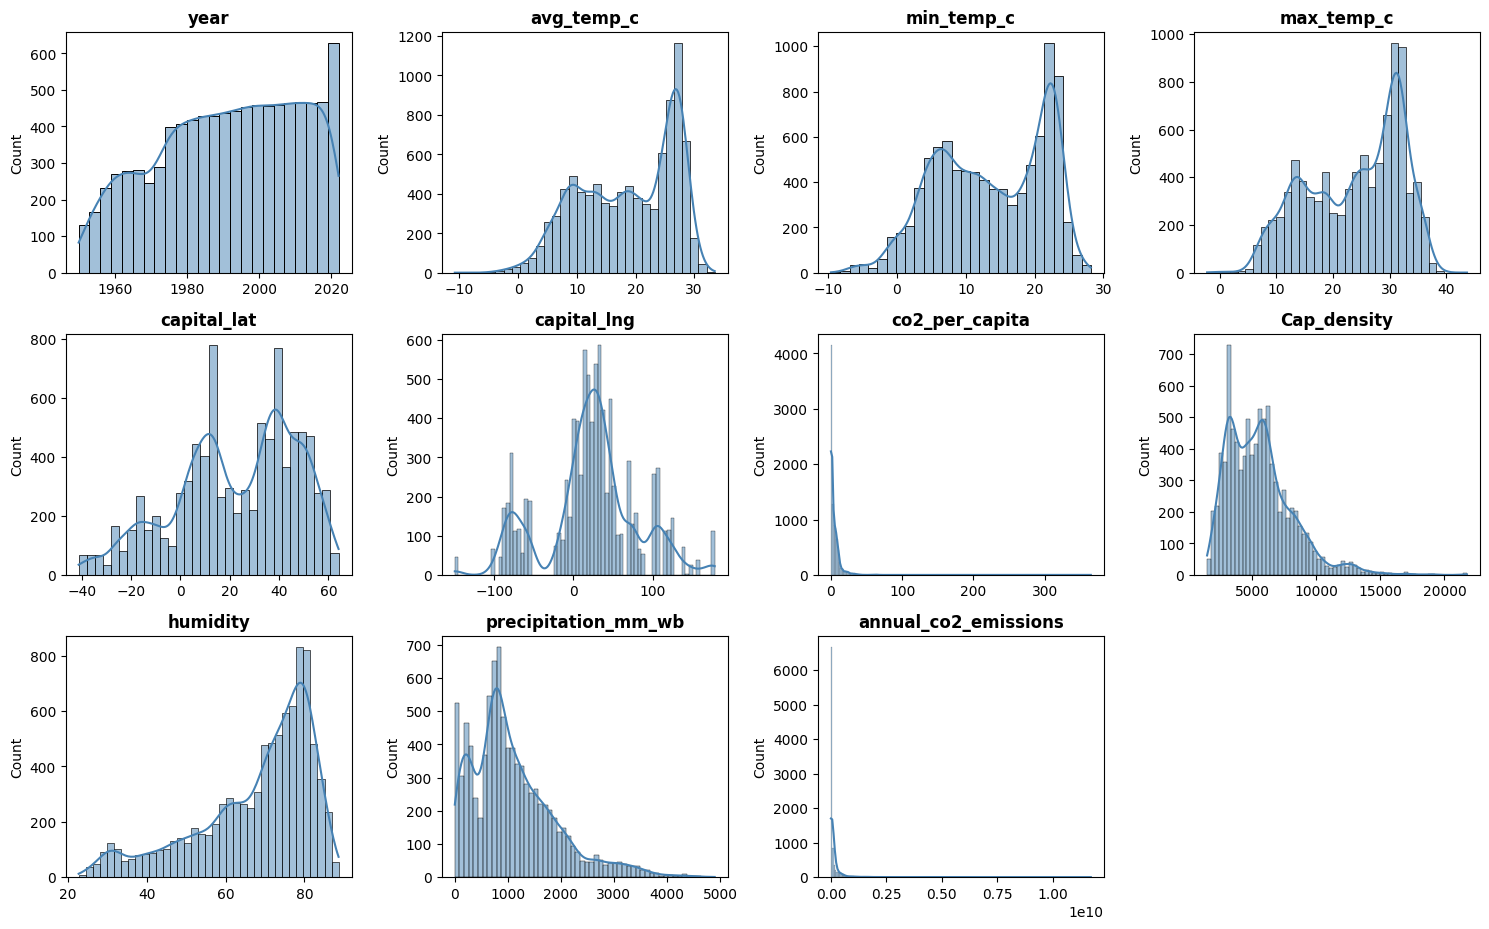

In [17]:
#check for data distribution 
# Select numeric features
numeric_cols =weather_data.select_dtypes(include=['number']).columns
# creade grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(15, 12))
axes = axes.flatten()
# create every plot alone
for i, col in enumerate(numeric_cols):
    sns.histplot(data=weather_data, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
# remove empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.savefig("Data/plots/01_EDA/08_distributions_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

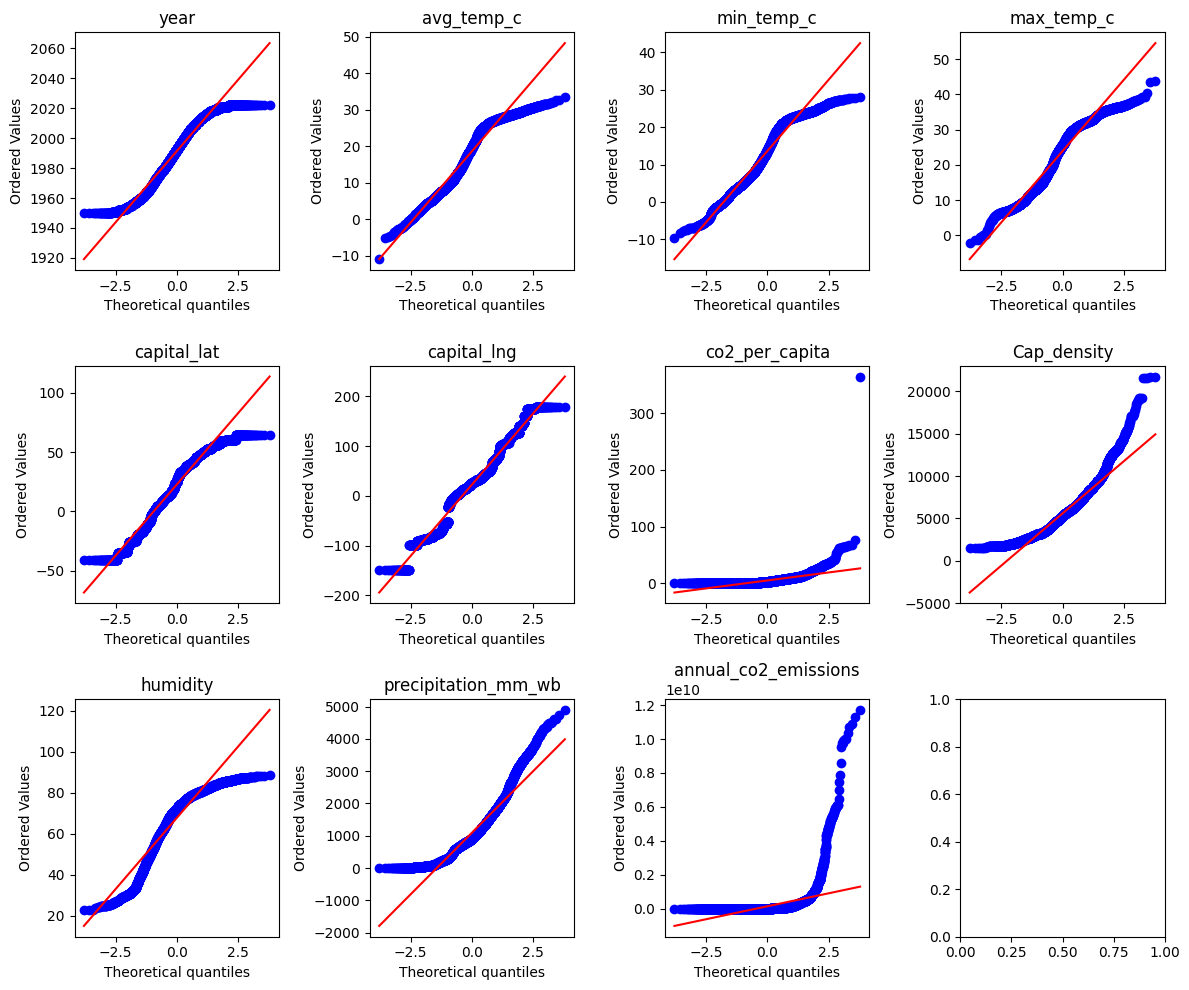

In [18]:
#also do a Q-Q plot to check for normal distribution
# Q-Q Plots
import scipy.stats as stats
# Create a figure with 3x3 grid of subplots (9 total)
# figsize sets the overall size in inches (width, height)
fig, axes = plt.subplots(3, 4, figsize=(12, 10))

# Flatten the 2D array of axes into 1D for easier indexing
# Before: [[ax0,ax1,ax2], [ax3,ax4,ax5], [ax6,ax7,ax8]]
# After:  [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]
axes = axes.flatten()

# Loop through each numeric column with its index
# enumerate gives us: (0,'Length'), (1,'Diameter'), (2,'Height'), ...
for i, col in enumerate(numeric_cols):
    # Create Q-Q plot for this column on the i-th subplot
    stats.probplot(weather_data[col], plot=axes[i])
    # Set the title of this subplot to the column name
    axes[i].set_title(col)

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()
# Display the figure
plt.savefig("Data/plots/01_EDA/09_qq_plots.png", dpi=150, bbox_inches="tight")
plt.show()
#Length, Diameter and Height show a normal distribution
#whole weight,shucked weight and viscera weight dont seem to be normal distributed
    

In [19]:
# 1. Quantitative: skewness and kurtosis
from scipy import stats
print(weather_data[numeric_cols].skew())      # |skew| < 0.5 is good
print(weather_data[numeric_cols].kurtosis())  # close to 0 is good




year                    -0.249415
avg_temp_c              -0.386146
min_temp_c              -0.236941
max_temp_c              -0.422881
capital_lat             -0.469460
capital_lng             -0.101275
co2_per_capita          13.589869
Cap_density              1.226852
humidity                -1.064424
precipitation_mm_wb      1.142622
annual_co2_emissions     9.598445
dtype: float64
year                     -0.979901
avg_temp_c               -1.048717
min_temp_c               -1.077537
max_temp_c               -1.011187
capital_lat              -0.587669
capital_lng               0.243536
co2_per_capita          546.755500
Cap_density               2.595460
humidity                  0.326097
precipitation_mm_wb       1.475115
annual_co2_emissions    115.688390
dtype: float64


## Distribution Analysis Summary

The distribution analysis (histograms, Q-Q plots, skewness/kurtosis) across all 11 numeric 
features reveals three distinct groups with different statistical properties and preprocessing needs.

---

### Feature Overview

| Feature | Shape | Skew | Kurtosis | Verdict |
|:---|:---:|---:|---:|:---|
| `avg_temp_c` | Bimodal | -0.40 | -1.06 | Not normal — two climate zones |
| `min_temp_c` | Bimodal | -0.25 | -1.09 | Not normal — two climate zones |
| `max_temp_c` | Bimodal | -0.44 | -1.02 | Not normal — two climate zones |
| `year` | Uniform | -0.25 | -0.97 | Not normal — growing data coverage |
| `capital_lat` | Mild S-curve | -0.45 | -0.61 | Acceptable, Northern Hemisphere bias |
| `capital_lng` | Near normal | -0.10 | +0.31 | Best-behaved geographic feature |
| `humidity` | Left-bounded | -1.10 | +0.39 | Mild left skew, usable |
| `precipitation_mm_wb` | Right skew | +1.14 | +1.50 | Moderate skew — log transform |
| `Cap_density` | Right skew | +1.24 | +2.65 | Moderate skew — log transform |
| `co2_per_capita` | Extreme right | **+13.7** | **+554** | Dominated by outliers — log transform |
| `annual_co2_emissions` | Extreme right | **+14.5** | **+270** | Dominated by outliers — log transform |

---

### Key Findings

**1. Bimodal temperature features**  
All three temperature variables show excess kurtosis of ~-1.0, the statistical fingerprint of 
two merged populations. The histograms confirm two peaks (~5–10°C and ~25–30°C), reflecting 
the mix of tropical and temperate countries in the dataset. Q-Q plots show a clear S-shaped 
deviation from normality. A `hemisphere` or `climate_zone` feature should be added before modelling 
to account for this structural split.

**2. Extreme skew in CO2 features**  
`co2_per_capita` (skew = 13.7, kurtosis = 554) and `annual_co2_emissions` (skew = 14.5, 
kurtosis = 270) are dominated by a small number of high-emitting countries. Kurtosis in the 
hundreds signals extreme outliers rather than just a long tail. Both features require 
log-transformation. `precipitation_mm_wb` and `Cap_density` show moderate right skew and 
should be treated likewise.

**3. Large sample caveat**  
With n = 9,281 observations, formal normality tests (Shapiro-Wilk, D'Agostino-Pearson) will 
reject H₀ for virtually every feature due to hypersensitivity at large sample sizes. 
Skewness, kurtosis, and Q-Q plots are more meaningful diagnostics at this scale.

---



In [20]:
# for the non-normal distributed data we can do a log transformation to see if it improves the distribution
weather_data['log_co2_per_capita']       = np.log1p(weather_data['co2_per_capita'])
weather_data['log_annual_co2_emissions'] = np.log1p(weather_data['annual_co2_emissions'])
weather_data['log_precipitation']        = np.log1p(weather_data['precipitation_mm_wb'])
weather_data['log_cap_density']          = np.log1p(weather_data['Cap_density'])
weather_data['climate_zone']             = weather_data['avg_temp_c'].apply(
                                               lambda t: 'tropical' if t > 18 else 'temperate')

print (weather_data.head())


       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1950   11.119662    4.298943   19.312555    34.526011   
1  Afghanistan  1951   12.800471    5.916646   19.600000    34.526011   
2  Afghanistan  1952   11.895238    5.432720   19.342222    34.526011   
3  Afghanistan  1953   11.998121    5.863144   19.135223    34.526011   
4  Afghanistan  1954   10.686849    4.435753   18.071644    34.526011   

   capital_lng  co2_per_capita  Cap_density hemisphere  humidity  \
0    69.177684        0.010837    3853.8767         NE     45.23   
1    69.177684        0.011625    3853.8767         NE     48.20   
2    69.177684        0.011468    3853.8767         NE     46.90   
3    69.177684        0.013123    3853.8767         NE     51.54   
4    69.177684        0.012945    3853.8767         NE     49.22   

   precipitation_mm_wb  annual_co2_emissions  log_co2_per_capita  \
0               349.26               84272.0            0.010779   
1               

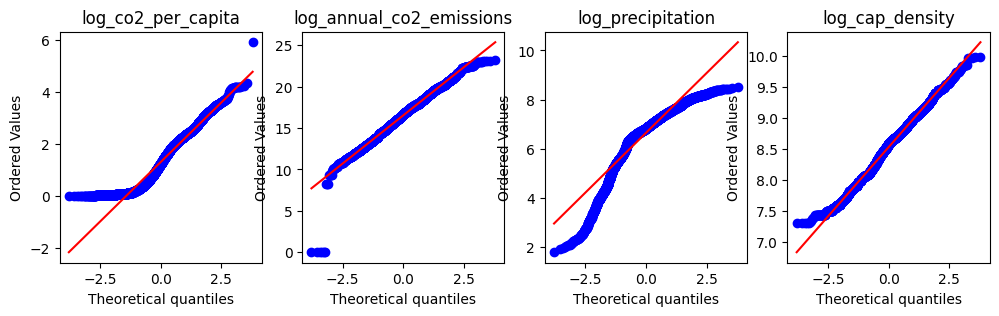

In [21]:
#look at the qq plots again after log transformation to see if the distribution has improved
# Q-Q Plots after log transformation
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes = axes.flatten()
log_cols = ['log_co2_per_capita', 'log_annual_co2_emissions', 'log_precipitation', 'log_cap_density']
for i, col in enumerate(log_cols):
    stats.probplot(weather_data[col], plot=axes[i])
    axes[i].set_title(col)
plt.savefig("Data/plots/01_EDA/10_qq_plots_log_transform.png", dpi=150, bbox_inches="tight")
plt.show()

## Log Transformation Results

Applying `log1p` to the four right-skewed features yielded mixed results.

| Feature | Result | Notes |
|:---|:---:|:---|
| `log_cap_density` |  Good | Near-normal, minor tail deviations only |
| `log_precipitation` |  Acceptable | Mild S-curve remains in lower tail |
| `log_co2_per_capita` |  Partial | One extreme outlier persists; slight bimodality (developing vs. high-income countries) |
| `log_annual_co2_emissions` |  Poor | Zero-inflation creates a hard floor at 0 — structural issue, transform cannot fix |

`log_annual_co2_emissions` is dropped from further analysis as `log_co2_per_capita` 
already captures emissions scaled to population size, making the absolute figure 
redundant and adding unnecessary multicollinearity.


In [22]:
import plotly.express as px

# One row per country per year - already have this in weather_data
map_df = weather_data.copy()

fig = px.scatter_geo(
    map_df,
    lat="capital_lat",
    lon="capital_lng",
    color="avg_temp_c",           # swap to "co2_per_capita" etc.
    hover_name="country",
    hover_data={"avg_temp_c": ":.1f", "co2_per_capita": ":.2f",
                "capital_lat": False, "capital_lng": False},
    animation_frame="year",
    color_continuous_scale="RdYlBu_r",
    range_color=[-10, 35],        # fix scale so animation is comparable
    size_max=12,
    projection="natural earth",
    title="Average Temperature by Capital City",
)

fig.update_layout(coloraxis_colorbar_title="°C")
fig.write_image("Data/plots/01_EDA/11_temperature_map.png", scale=2)
fig.show()



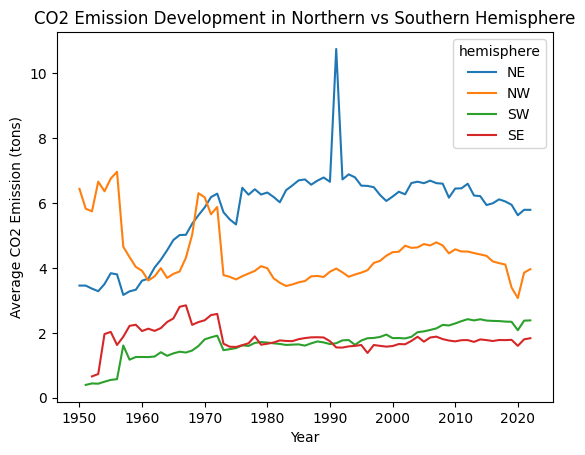

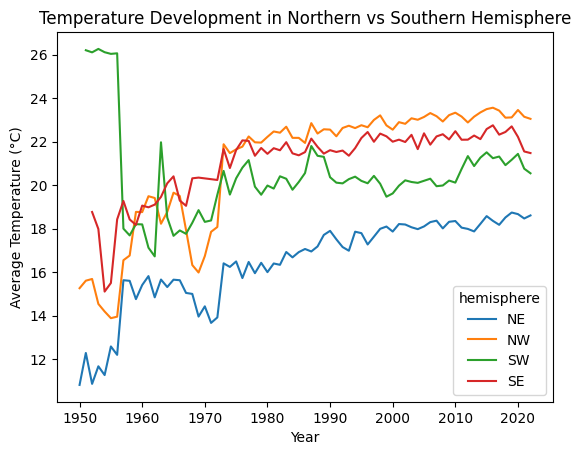

In [23]:
#plot the temperature development in the different hemispheres
co2_hemisphere = weather_data.groupby(["year", "hemisphere"])["co2_per_capita"].mean().reset_index()
temp_hemisphere = weather_data.groupby(["year", "hemisphere"])["avg_temp_c"].mean().reset_index()
sns.lineplot(x="year", y="co2_per_capita", hue="hemisphere", data=co2_hemisphere)
plt.xlabel("Year")
plt.ylabel("Average CO2 Emission (tons)")
plt.title("CO2 Emission Development in Northern vs Southern Hemisphere")
plt.savefig("Data/plots/01_EDA/12_hemisphere_co2.png", dpi=150, bbox_inches="tight")
plt.show()
sns.lineplot(x="year", y="avg_temp_c", hue="hemisphere", data=temp_hemisphere)
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Temperature Development in Northern vs Southern Hemisphere")
plt.savefig("Data/plots/01_EDA/13_hemisphere_temperature.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#select climate dirving features for PCA
features = ['avg_temp_c', 'humidity', 'precipitation_mm_wb',
            'co2_per_capita', 'capital_lat']

# One representative profile per country
country_profiles = weather_data.groupby('country')[features].mean()

scaler = StandardScaler()
scaled = scaler.fit_transform(country_profiles)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

country_profiles['pca_one'] = pca_result[:, 0]
country_profiles['pca_two'] = pca_result[:, 1]

# Merge hemisphere back for coloring
country_profiles = country_profiles.merge(
    weather_data[['country', 'hemisphere']].drop_duplicates(),
    on='country'
)

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%}")
print(pd.DataFrame(pca.components_, columns=features, index=['PC1','PC2']).round(2))



Explained variance: PC1=42.0%, PC2=31.2%
     avg_temp_c  humidity  precipitation_mm_wb  co2_per_capita  capital_lat
PC1       -0.46     -0.25                -0.53            0.39         0.54
PC2       -0.43      0.71                 0.44            0.15         0.30


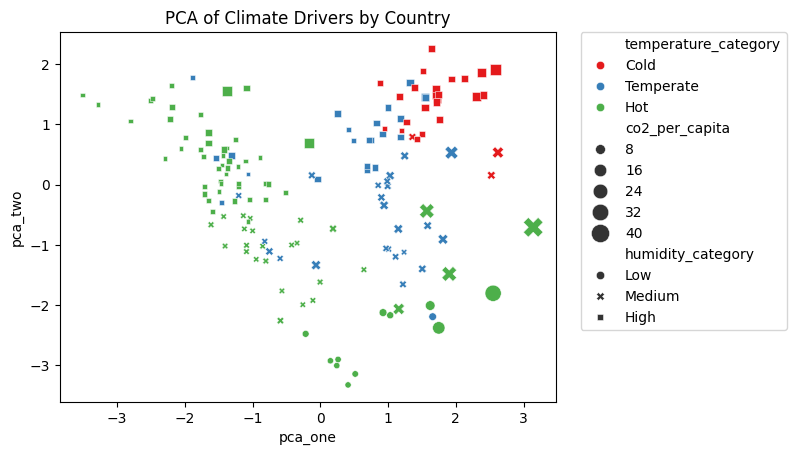

In [25]:

country_profiles['humidity_category'] = pd.cut(country_profiles['humidity'], bins=[0, 40, 70, 100], labels=['Low', 'Medium', 'High'])
country_profiles["temperature_category"] = pd.cut(country_profiles['avg_temp_c'], bins=[-10, 10, 20, 30], labels=['Cold', 'Temperate', 'Hot'])
sns.scatterplot(
    x='pca_one', y='pca_two',
    hue='temperature_category',
    size='co2_per_capita',
    style='humidity_category',
    sizes=(20, 200),         
    data=country_profiles,
    palette='Set1'
)
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.title("PCA of Climate Drivers by Country")
plt.savefig("Data/plots/02_Clustering/01_pca_climate_drivers.png", dpi=150, bbox_inches="tight")
plt.show()


In [26]:


map_df = country_profiles.reset_index()
map_df = map_df.merge(
    weather_data[['country', 'capital_lng']].drop_duplicates('country'),
    on='country'
)

# PC1 map
fig = px.scatter_geo(
    map_df,
    lat='capital_lat',
    lon='capital_lng',
    color='pca_one',
    hover_name='country',
    hover_data={"co2_per_capita": ':.2f', "capital_lat": ':.2f', "capital_lng": ':.2f', "avg_temp_c": ':.1f'},
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    projection='natural earth',
     title='PC1 — Tropical / wet / low-CO₂ (red)  vs  Dry / high-latitude / high-CO₂ (blue)',
)
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color='black')))
fig.write_image("Data/plots/02_Clustering/02_pca_pc1_map.png", scale=2)
fig.show()

# PC2 map
fig2 = px.scatter_geo(
    map_df,
    lat='capital_lat',
    lon='capital_lng',
    color='pca_two',
    hover_name='country',
    hover_data={"humidity": ':.1f', "precipitation_mm_wb": ':.1f', "capital_lat": ':.2f', "avg_temp_c": ':.1f'},
    color_continuous_scale='BrBG',
    color_continuous_midpoint=0,
    projection='natural earth',
    title='PC2 — Arid (brown) vs Humid (green)',
)
fig2.update_traces(marker=dict(size=10, line=dict(width=0.5, color='black')))
fig2.write_image("Data/plots/02_Clustering/03_pca_pc2_map.png", scale=2)
fig2.show()


In [27]:
# Top 5 (most blue) and bottom 5 (most red)
extremes = pd.concat([
    country_profiles.nlargest(5, 'pca_one'),
    country_profiles.nsmallest(5, 'pca_one')
])

print(extremes[['pca_one', 'avg_temp_c', 'co2_per_capita', 'capital_lat', 'precipitation_mm_wb',"country"]].round(2))


     pca_one  avg_temp_c  co2_per_capita  capital_lat  precipitation_mm_wb  \
114     3.14       27.98           47.51        25.29                61.23   
72      2.62        5.63           12.58        51.13               331.03   
83      2.59        9.02           27.33        49.82               895.11   
74      2.55       26.87           30.69        29.38               117.15   
94      2.52        0.58            4.30        47.92               282.91   
108    -3.51       28.01            0.70        -9.47              4014.78   
125    -3.28       27.11            0.42        -9.43              3740.94   
63     -2.80       27.30            1.12        -6.18              3142.76   
29     -2.51       24.74            1.57         4.60              3369.86   
31     -2.48       25.68            1.28         9.93              3374.88   

              country  
114             Qatar  
72         Kazakhstan  
83         Luxembourg  
74             Kuwait  
94           Mongolia

## 4. PCA of Country Climate Profiles

### Methodology

PCA was applied to **country-level mean profiles** (one row per country, 161 countries)
rather than the full time-series. This avoids conflating within-country temporal change
with between-country climate differences.

Features used (all standardised with `StandardScaler` before fitting):

| Feature               | Role                    |
|:----------------------|:------------------------|
| `avg_temp_c`          | Core climate signal     |
| `humidity`            | Moisture dimension      |
| `precipitation_mm_wb` | Rainfall                |
| `co2_per_capita`      | Emissions intensity     |
| `capital_lat`         | Geographic proxy        |

> `Cap_density` loaded near zero on both components (−0.05, −0.13) and was dropped.

---

### Results

**PC1 — 42.0% of variance: Aridity & Development axis**

The strongest loadings on PC1 are **latitude (+0.54)** and
**precipitation (−0.53)**, not temperature (−0.46).
Temperature appears influential but is largely collinear with latitude —
it is a correlated passenger rather than an independent driver.

| Loading              | Value | Interpretation                        |
|:---------------------|:-----:|:--------------------------------------|
| `capital_lat`        | +0.54 | Higher latitude → positive PC1        |
| `precipitation_mm_wb`| −0.53 | Drier climate → positive PC1          |
| `avg_temp_c`         | −0.46 | Cooler temperature → positive PC1     |
| `co2_per_capita`     | +0.39 | Higher emissions → positive PC1       |

| Direction                        | Score    | Example countries                      |
|:---------------------------------|:--------:|:---------------------------------------|
| High-latitude, dry, high-CO₂     | Positive | Qatar, Kazakhstan, Luxembourg, Kuwait  |
| Tropical, wet, low-CO₂           | Negative | Papua New Guinea, Indonesia, Colombia  |

> **Notable anomaly:** Qatar and Kuwait are *hot* climates yet score highest on PC1
> because their extreme CO₂ per capita (47 and 31 t respectively) overrides both
> the temperature and low-latitude signal. They are development outliers, not
> climate outliers.

**PC2 — 31.2% of variance: Aridity within the tropics**

| Loading              | Value | Interpretation                      |
|:---------------------|:-----:|:------------------------------------|
| `humidity`           | +0.71 | Higher humidity → positive PC2      |
| `precipitation_mm_wb`| +0.44 | More rainfall → positive PC2        |
| `avg_temp_c`         | −0.43 | Cooler → positive PC2               |

| Direction       | Score    | Example countries            |
|:----------------|:--------:|:-----------------------------|
| Humid tropical  | Positive | Congo, Indonesia, Caribbean  |
| Hot and arid    | Negative | Sahara belt, Middle East     |

**Total explained variance: 73.2%** across two components.

---

### Geographic Validation

The PCA scores were projected onto a world map **without using geographic labels
during fitting** and reproduced two known climatological patterns:

- **PC1** — the latitude gradient and desert belt (low-precipitation continental interiors)
- **PC2** — the humid tropics vs. the Sahara/Arabian arid zone

---

### Key Takeaway

PC1 is best understood as an **aridity + development axis**, not a temperature axis.
The Gulf states (Qatar, Kuwait) demonstrate this clearly: hot-climate countries
that rank at the *top* of PC1 purely due to extreme per-capita emissions.
The tropical low-emitters at the bottom are simultaneously the most humid and
precipitation-rich regions on earth — facing the highest climate exposure
while contributing the least to emissions.


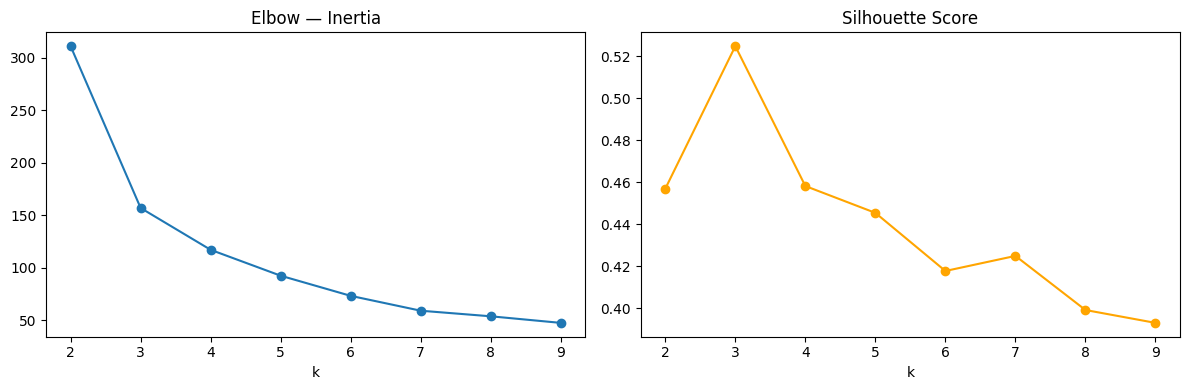

In [28]:
import os
os.environ['OMP_NUM_THREADS'] = '1'  # prevents KMeans memory leak on Windows with MKL

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# We cluster on the two PCA scores rather than the raw features.
# This removes multicollinearity (e.g. temp and latitude are correlated)
# and puts all variance on a common scale without needing to re-standardise.
X = country_profiles[['pca_one', 'pca_two']].values

inertias, silhouettes = [], []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    
    # Inertia = sum of squared distances from each point to its cluster centre.
    # We look for the "elbow" — the k where adding more clusters
    # gives diminishing returns in inertia reduction.
    inertias.append(km.inertia_)
    
    # Silhouette score measures how similar a point is to its own cluster
    # vs. neighbouring clusters. Ranges from -1 to 1; higher is better.
    # Use this alongside the elbow to confirm the choice of k.
    silhouettes.append(silhouette_score(X, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K, inertias, marker='o')
ax1.set_title('Elbow — Inertia')
ax1.set_xlabel('k')

ax2.plot(K, silhouettes, marker='o', color='orange')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('k')
plt.tight_layout()
plt.savefig("Data/plots/02_Clustering/04_kmeans_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()


In [29]:
#k =3 is optimal as it is the elbow point and also has the highest silhouette score
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
country_profiles['cluster'] = km.fit_predict(X).astype(str)


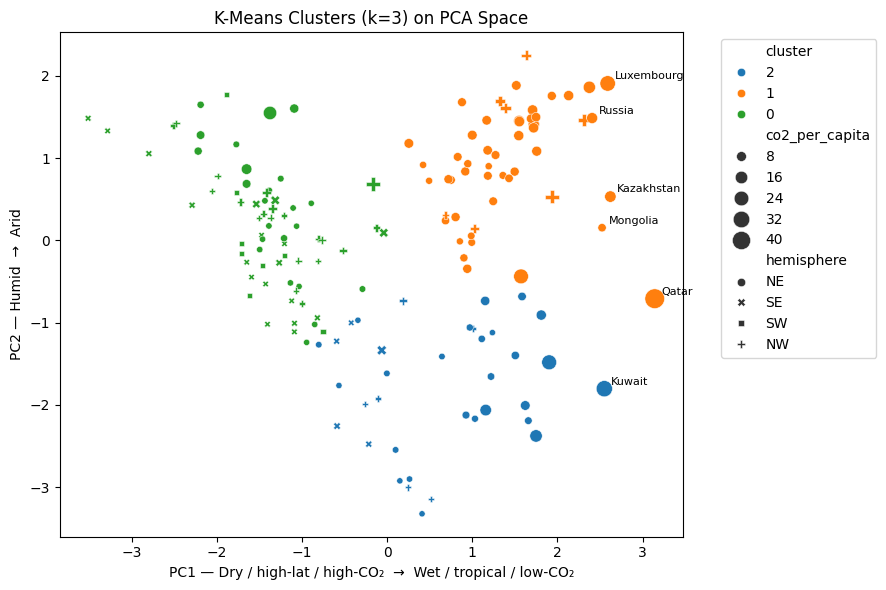

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    x='pca_one', y='pca_two',
    hue='cluster',
    size='co2_per_capita',
    style ='hemisphere',
    sizes=(20, 200),
    data=country_profiles,
    palette='tab10',
    ax=ax
)
for _, row in country_profiles[country_profiles['pca_one'] > 2.4].iterrows():
    ax.annotate(row['country'], xy=(row['pca_one'], row['pca_two']),
                xytext=(5, 3), textcoords='offset points', fontsize=8)

ax.set_xlabel("PC1 — Dry / high-lat / high-CO₂  →  Wet / tropical / low-CO₂")
ax.set_ylabel("PC2 — Humid  →  Arid")
ax.set_title(f"K-Means Clusters (k={k}) on PCA Space")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.savefig("Data/plots/02_Clustering/05_kmeans_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()


In [31]:
profile_cols = ['avg_temp_c', 'co2_per_capita', 'precipitation_mm_wb', 'humidity', 'capital_lat']
print(country_profiles.groupby('cluster')[profile_cols].mean().round(2).sort_values('avg_temp_c', ascending=False))


         avg_temp_c  co2_per_capita  precipitation_mm_wb  humidity  \
cluster                                                              
0             24.26            2.17              1849.01     75.94   
2             23.23            4.19               324.81     45.44   
1             10.87            8.34               847.30     73.11   

         capital_lat  
cluster               
0               1.16  
2              18.25  
1              46.05  


In [32]:
cluster_names = {
    '0': 'Tropical humid / low-CO₂',
    '2': 'Arid / mixed-CO₂',
    '1': 'High-latitude / industrial'
}
country_profiles['cluster_name'] = country_profiles['cluster'].map(cluster_names)

# capital_lng was lost during aggregation — merge it back from weather_data
country_profiles = country_profiles.merge(
    weather_data[['country', 'capital_lng']].drop_duplicates('country'),
    on='country',
    how='left'
)

fig = px.scatter_geo(
    country_profiles,
    lat='capital_lat',
    lon='capital_lng',
    color='cluster_name',
    hover_name='country',
    hover_data={"humidity": ':.1f', "precipitation_mm_wb": ':.1f', "co2_per_capita": ':.1f', "avg_temp_c": ':.1f'},
    color_discrete_map={
        'Tropical humid / low-CO₂':   'seagreen',
        'Arid / mixed-CO₂':           'sandybrown',
        'High-latitude / industrial': 'steelblue'
    },
    projection='natural earth',
    title='Country Climate Clusters (k=3)',
)
fig.update_traces(marker=dict(size=10, line=dict(width=0.5, color='black')))
fig.show()


In [33]:
#add the clusters to weater_data for later use in the model
# add the clusters to weather_data for later use in the model
weather_data = weather_data.merge(
    country_profiles[['country', 'cluster', 'cluster_name']].drop_duplicates('country'),
    on='country',
    how='left'
)
weather_data = weather_data.drop(columns=['climate_zone'])

print(weather_data.head())

       country  year  avg_temp_c  min_temp_c  max_temp_c  capital_lat  \
0  Afghanistan  1950   11.119662    4.298943   19.312555    34.526011   
1  Afghanistan  1951   12.800471    5.916646   19.600000    34.526011   
2  Afghanistan  1952   11.895238    5.432720   19.342222    34.526011   
3  Afghanistan  1953   11.998121    5.863144   19.135223    34.526011   
4  Afghanistan  1954   10.686849    4.435753   18.071644    34.526011   

   capital_lng  co2_per_capita  Cap_density hemisphere  humidity  \
0    69.177684        0.010837    3853.8767         NE     45.23   
1    69.177684        0.011625    3853.8767         NE     48.20   
2    69.177684        0.011468    3853.8767         NE     46.90   
3    69.177684        0.013123    3853.8767         NE     51.54   
4    69.177684        0.012945    3853.8767         NE     49.22   

   precipitation_mm_wb  annual_co2_emissions  log_co2_per_capita  \
0               349.26               84272.0            0.010779   
1               

## 5. K-Means Clustering of Country Climate Profiles

### Methodology

K-Means clustering was applied to the two PCA scores (`pca_one`, `pca_two`) rather
than the raw features. This approach avoids multicollinearity and ensures all variance
is already on a comparable scale from the PCA step.

The optimal number of clusters was determined using two complementary metrics:

- **Elbow (inertia)**: sharpest bend at k=3
- **Silhouette score**: clear peak at k=3 (score = 0.53)

Both metrics agreed, making k=3 an unambiguous choice.

---

### Cluster Profiles

| Cluster | Avg Temp | CO₂/capita | Precipitation | Humidity | Latitude |
|:--------|:--------:|:----------:|:-------------:|:--------:|:--------:|
| Tropical humid / low-CO₂   | 24.3°C | 2.2 t | 1849 mm | 76% |  1°N |
| Arid / mixed-CO₂           | 23.2°C | 4.2 t |  325 mm | 45% | 18°N |
| High-latitude / industrial | 10.9°C | 8.3 t |  847 mm | 73% | 46°N |

---

### Key Findings

**1. Temperature does not separate the clusters.**
The tropical and arid clusters share almost identical mean temperatures (24.3 vs 23.2°C).
What separates them is precipitation — a factor of **6×** difference (1849 vs 325 mm).
This confirms the earlier PCA finding that PC1 is an aridity + development axis,
not a temperature axis.

**2. The arid cluster bridges two very different country types.**
The Sahel/desert nations and the Gulf states (Qatar, Kuwait) end up in the same
cluster because they share extreme dryness on PC2 — despite having CO₂ profiles
that differ by an order of magnitude. This is not a flaw; it reflects a genuine
shared physical characteristic.

**3. The equity dimension is quantified.**
The high-latitude industrial cluster emits **3.8× more CO₂ per capita** than the
tropical cluster (8.3 vs 2.2 t), while being on average 35° further from the equator
and significantly cooler. Cold industrial nations drive emissions; hot humid tropical
nations bear the climate exposure.

---

### Geographic Validation

The cluster labels were projected onto a world map after fitting — no coordinates
were used during PCA or K-Means. The result reproduced three well-known
geographic zones:

- The **industrial band** across Europe, Russia, and East Asia (blue)
- The **tropical belt** across Sub-Saharan Africa, Southeast Asia, and Latin America (green)
- The **global arid zone** threading from the Sahara through the Arabian Peninsula
  to Central Asia (orange) — emerging as an almost perfect latitudinal band at 15–35°N

The unsupervised recovery of these known climate regions confirms that the
feature set captured real physical structure in the data.

---

### Next Steps

The three cluster labels (`Tropical humid`, `Arid`, `High-latitude / industrial`)
will be carried forward as a categorical feature in the predictive modelling phase,
where the goal is to predict country-level average temperature from climate
and emissions variables.


In [34]:
#Temperature anomaly (how much warmer than that country's historical average) →
#  CO₂ and year become much more meaningful, and the question becomes interesting

# Use 1950-1980 as the pre-acceleration baseline
# (CO2 growth accelerated sharply after ~1980)
baseline = (
    weather_data[weather_data['year'] <= 1980]
    .groupby('country')['avg_temp_c']
    .mean()
    .rename('baseline_temp')
)

weather_data = weather_data.merge(baseline, on='country', how='left')

# Anomaly = how much warmer than the country's own historical average
weather_data['temp_anomaly'] = weather_data['avg_temp_c'] - weather_data['baseline_temp']


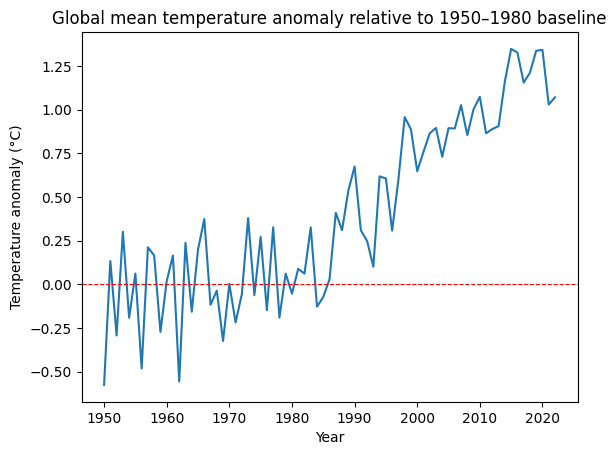

In [35]:
# Global mean anomaly per year — should show warming trend
anomaly_per_year = weather_data.groupby('year')['temp_anomaly'].mean()

sns.lineplot(x=anomaly_per_year.index, y=anomaly_per_year.values)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('Temperature anomaly (°C)')
plt.title('Global mean temperature anomaly relative to 1950–1980 baseline')
plt.savefig("Data/plots/03_Anomaly/01_global_mean_anomaly.png", dpi=150, bbox_inches="tight")
plt.show()


In [36]:
features = [
    'log_co2_per_capita',        # primary emissions driver
    'log_annual_co2_emissions',  # total national output
    'year',                      # captures global warming trend
    'humidity',                  # climate feedback
    'log_precipitation',         # climate feedback
    'cluster_name',              # regime — anomaly may differ by climate zone
    'hemisphere',                # seasonal/structural difference
    'log_cap_density',           # urbanisation — heat island effect
]

target = 'temp_anomaly'


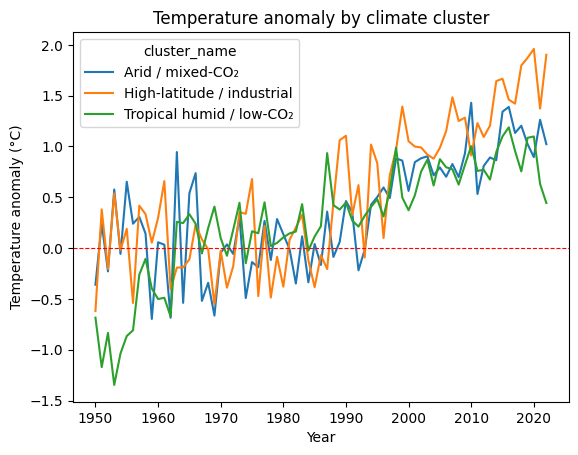

In [37]:
anomaly_by_cluster = weather_data.groupby(['year', 'cluster_name'])['temp_anomaly'].mean().reset_index()
weather_data.dropna(subset=['temp_anomaly'], inplace=True)
sns.lineplot(data=anomaly_by_cluster, x='year', y='temp_anomaly', hue='cluster_name')
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('Temperature anomaly (°C)')
plt.title('Temperature anomaly by climate cluster')
plt.savefig("Data/plots/03_Anomaly/02_anomaly_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Temperature Anomaly Analysis

### Definition

The temperature anomaly measures how much warmer (or cooler) a country is in a given
year compared to its own historical baseline — defined here as its mean temperature
over **1950–1980**, the pre-acceleration period before CO₂ emissions grew sharply.

$$\text{anomaly}_{c,t} = \text{avg\_temp}_{c,t} - \overline{\text{avg\_temp}}_{c,\ 1950\text{–}1980}$$

This removes the country-level geographic constant (latitude, elevation, etc.),
leaving only **change over time** as the signal. CO₂, year, and emissions
therefore have something meaningful to explain.

---

### Global Warming Signal

The global mean anomaly plot shows a clear and accelerating warming trend:

- **1950–1980**: oscillates around 0°C — expected, this is the baseline period
- **~1990**: the anomaly crosses zero **permanently** — no country has experienced
  a "normal" year by its own historical standard since then
- **2000–2022**: accelerating upward, reaching +1.0 to +1.3°C by 2020

---

### Anomaly by Climate Cluster

Splitting the anomaly by the three K-Means clusters reveals an unexpected result:

| Observation | Implication |
|:------------|:------------|
| All three clusters warm at roughly the **same rate** from 1990 onwards | Warming is global and simultaneous — not concentrated in one climate zone |
| The **tropical cluster** shows the highest early volatility (±1.5°C, 1950–1970) | Fewer weather stations in tropical countries during the early period — noisier baseline |
| The **arid cluster** tracks closely with high-latitude | Desert regions are warming as rapidly as industrial nations |
| No clear Arctic amplification signal in this dataset | Likely a resolution effect — country-level annual means smooth out the polar signal |

---

### Implications for Modelling

The anomaly analysis motivates the following modelling decisions:

- **Target**: `temp_anomaly` rather than absolute temperature — removes geographic
  confounding and makes CO₂ and time the primary drivers
- **`year`** will be the strongest predictor — the trend dominates all clusters
- **`log_co2_per_capita`** is the key variable of interest — does emissions
  intensity add predictive signal on top of the global time trend?
- **`cluster_name`** may help explain year-to-year variance rather than
  the long-run trend, since warming rates converge across clusters

**On geographic coordinates:**
`capital_lat` and `capital_lng` are retained in the feature set and their importance
assessed empirically after fitting. The baseline subtraction already absorbs the
country-level geographic constant, so coordinates would only add signal if warming
*rates* differ by latitude — i.e. Arctic amplification. The cluster plot suggests
this effect is weak in this dataset, but the decision is left to the model:
if feature importance for `capital_lat` is near zero after fitting, it will be dropped.


In [38]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [39]:
#prepare data for modeling
# Features per Section 6 analysis + geographic coords for empirical importance check
feature_cols = [
    'log_co2_per_capita',    # primary emissions driver
    'year',                  # captures global warming trend
    'humidity',              # climate feedback
    'log_precipitation',     # climate feedback
    'log_cap_density',       # urbanisation / heat island
    'capital_lat',           # geographic — drop if importance near zero
    'capital_lng',
    'cluster_name',          # climate regime
    'hemisphere',
    "country"
]

x = weather_data[feature_cols].copy()
y = weather_data['temp_anomaly']

In [40]:
# Encode categoricals before splitting
from calendar import c


le = LabelEncoder()

x['cluster_name'] = le.fit_transform(x['cluster_name'])
x['hemisphere']   = le.fit_transform(x['hemisphere'])
x['country']      = le.fit_transform(x['country'])

# Temporal split — train on past, test on future (no random shuffle)
# Random split would leak: model sees 2020 anomalies and "predicts" 2015 (trivial interpolation)
split_year = 2010
mask_train = weather_data['year'] <= split_year
mask_test  = weather_data['year'] >  split_year

x_train, x_test = x[mask_train], x[mask_test]
y_train, y_test = y[mask_train], y[mask_test]

print(f"Train: {x_train.shape}  ({weather_data.loc[mask_train,'year'].min()}–{weather_data.loc[mask_train,'year'].max()})")
print(f"Test:  {x_test.shape}  ({weather_data.loc[mask_test,'year'].min()}–{weather_data.loc[mask_test,'year'].max()})")

Train: (6976, 10)  (1950–2010)
Test:  (1673, 10)  (2011–2022)


In [41]:
# Scale AFTER splitting — fit only on train so test distribution doesn't influence the scaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)   # learn mean/std from train only
x_test_scaled  = scaler.transform(x_test)         # apply same scale to test

Linear Regression — RMSE: 1.3716°C,  R²: 0.0120


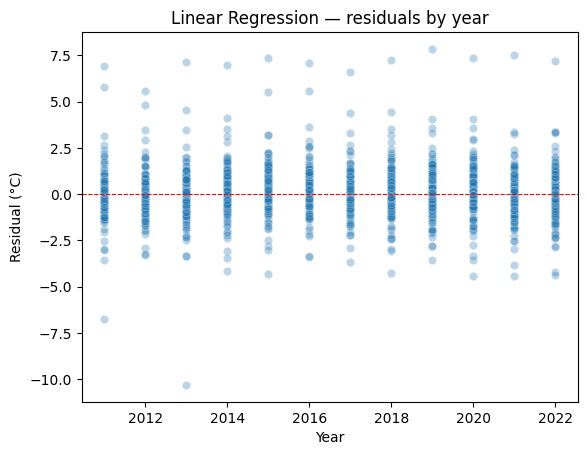

In [42]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

y_pred_lr = lr.predict(x_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
print(f"Linear Regression — RMSE: {rmse_lr:.4f}°C,  R²: {r2_lr:.4f}")

# Residual plot — country-level model, test set only
residuals  = y_test - y_pred_lr
test_years = weather_data.loc[x_test.index, 'year']

sns.scatterplot(x=test_years, y=residuals, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('Residual (°C)')
plt.title('Linear Regression — residuals by year')
plt.savefig("Data/plots/04_Models/01_linear_regression_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Linear Regression — Results

### Setup
- **Train**: 1950–2010 | **Test**: 2011–2022 (temporal split — no random shuffle)
- **Features**: `log_co2_per_capita`, `year`, `humidity`, `log_precipitation`, `log_cap_density`, `capital_lat`, `capital_lng`, `cluster_name`, `hemisphere`
- **Target**: `temp_anomaly` (°C deviation from each country's 1950–1980 baseline)

---

### Results

| Metric | Value | Interpretation |
|:-------|------:|:---------------|
| RMSE   | 1.37°C | Average prediction error — larger than the signal itself (~1°C by 2022) |
| R²     | 0.01   | Explains 1% of variance — essentially no predictive power |

---

### Residual Analysis

The residual plot (residuals vs. year) shows:
- Residuals are **centred around 0** across all test years — no systematic bias, the model tracks the mean trend correctly
- Spread is **±7.5°C** — the model knows the direction but fails on individual country predictions
- No clear trend in residuals by year — the model is not systematically under- or over-predicting the post-2010 acceleration

---

### Why the Model Fails

`temp_anomaly` has two components:

1. **Global trend** (~0.02°C/year) — linear regression captures this via `year`
2. **Country-level noise** (±3–7°C within-year spread) — this completely swamps the trend signal

The RMSE of 1.37°C is larger than the entire warming signal the model is trying to predict. At the individual country level, the predictions are no better than guessing the mean.

Linear regression cannot capture:
- Non-linear interactions (e.g. `year × cluster_name` — arid vs. tropical warming rates)
- Country-specific warming trajectories
- Threshold effects in CO₂ response

---

### Conclusion

Linear regression serves as a **weak baseline**. The 1.37°C RMSE is the target to beat.
Random Forest is expected to improve substantially by learning feature interactions.

In [43]:
#instead for lineear regression we will instead aggregate to a yearly global mean

yearly_global = weather_data.groupby('year').agg(
    temp_anomaly            = ('temp_anomaly',            'mean'),
    annual_co2_emissions    = ('annual_co2_emissions',    'sum'),   # total global output
    humidity                = ('humidity',                'mean'),
    log_precipitation       = ('log_precipitation',       'mean'),
).reset_index()

print (yearly_global.head())


   year  temp_anomaly  annual_co2_emissions   humidity  log_precipitation
0  1950     -0.575808          4.760431e+09  67.571944           6.418202
1  1951      0.133072          5.241787e+09  68.703571           6.474655
2  1952     -0.292574          5.657030e+09  69.119811           6.544146
3  1953      0.300608          5.844622e+09  70.114815           6.577632
4  1954     -0.191157          5.941701e+09  71.307273           6.651575


In [44]:
#linear regression on the yearly global data
x_linear = yearly_global.drop(columns=['temp_anomaly'])
y_linear = yearly_global['temp_anomaly']


lr_global = LinearRegression()
#split into train and test
split_year = 2010
mask_train = yearly_global['year'] <= split_year
mask_test  = yearly_global['year'] >  split_year
x_train_linear, x_test_linear = x_linear[mask_train], x_linear[mask_test]
y_train_linear, y_test_linear = y_linear[mask_train], y_linear[mask_test]
lr_global.fit(x_train_linear, y_train_linear)

y_pred_lr = lr_global.predict(x_test_linear)
rmse_lr = np.sqrt(mean_squared_error(y_test_linear, y_pred_lr))
r2_lr   = r2_score(y_test_linear, y_pred_lr)
print(f"Linear Regression (global) — RMSE: {rmse_lr:.4f}°C,  R²: {r2_lr:.4f}")

#interpret the coefficients of the linear regression model
coef_df = pd.DataFrame({
    'feature': x_linear.columns,
    'coefficient': lr_global.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df)

Linear Regression (global) — RMSE: 0.1946°C,  R²: -0.2134
                feature   coefficient
3     log_precipitation -1.344246e+00
0                  year  2.094669e-02
2              humidity  5.497760e-03
1  annual_co2_emissions  5.704486e-12


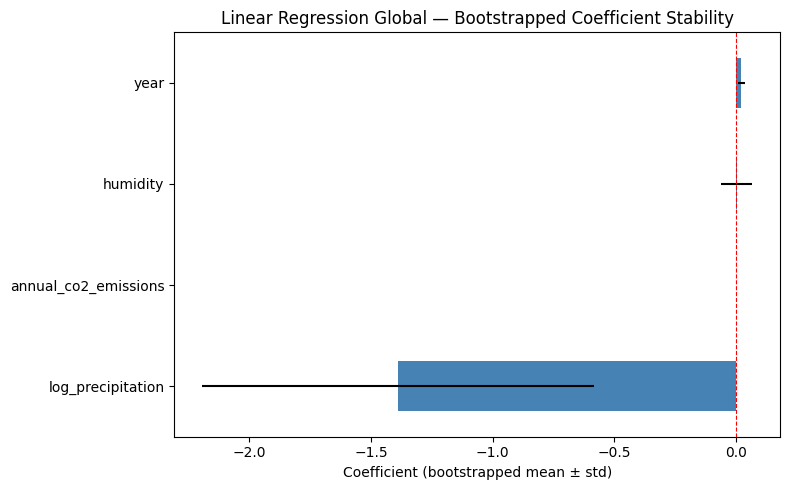

                              mean           std
log_precipitation    -1.388734e+00  8.056625e-01
annual_co2_emissions  5.705320e-12  3.451977e-11
humidity              3.571594e-03  6.416898e-02
year                  2.097368e-02  1.412690e-02


In [45]:
from sklearn.utils import resample

bootstrap_coefs_lr_global = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    X_bs, y_bs = resample(x_train_linear, y_train_linear, random_state=None)
    lr_bs = LinearRegression()
    lr_bs.fit(X_bs, y_bs)
    bootstrap_coefs_lr_global.append(lr_bs.coef_)

coef_df_lr_global = pd.DataFrame(bootstrap_coefs_lr_global, columns=x_linear.columns)

means_lr_global = coef_df_lr_global.mean().sort_values()
stds_lr_global  = coef_df_lr_global.std().reindex(means_lr_global.index)

means_lr_global.plot(kind='barh', figsize=(8, 5), color='steelblue', xerr=stds_lr_global)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient (bootstrapped mean ± std)')
plt.title('Linear Regression Global — Bootstrapped Coefficient Stability')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/02_linear_global_bootstrap_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.DataFrame({'mean': means_lr_global, 'std': stds_lr_global}))


In [46]:
from sklearn.preprocessing import PolynomialFeatures

# Add year² to capture accelerating trend
poly = PolynomialFeatures(degree=2, include_bias=False)
x_poly = pd.DataFrame(
    poly.fit_transform(yearly_global[['year']]),
    columns=['year', 'year_sq']
)
# Combine with other features
x_poly[['annual_co2_emissions','humidity','log_precipitation']] = \
    yearly_global[['annual_co2_emissions','humidity','log_precipitation']].values
y = yearly_global['temp_anomaly']

# Same temporal split
mask_train = yearly_global['year'] <= 2010
mask_test  = yearly_global['year'] >  2010
x_train_p, x_test_p = x_poly[mask_train], x_poly[mask_test]
y_train,   y_test   = y[mask_train],       y[mask_test]

# Scale — year² has values ~4,000,000, dwarfs everything else without scaling
scaler_poly = StandardScaler()
x_train_ps = scaler_poly.fit_transform(x_train_p)
x_test_ps  = scaler_poly.transform(x_test_p)


In [47]:
lr_poly = LinearRegression()
lr_poly.fit(x_train_ps, y_train)
y_pred_poly = lr_poly.predict(x_test_ps)

rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))
r2_poly   = r2_score(y_test, y_pred_poly)
print(f"Polynomial LR — RMSE: {rmse_poly:.4f}°C,  R²: {r2_poly:.4f}")

# Interpret coefficients
coef_df_poly = pd.DataFrame({
    'feature': x_poly.columns,
    'coefficient': lr_poly.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df_poly)


Polynomial LR — RMSE: 0.4324°C,  R²: -4.9927
                feature  coefficient
1               year_sq    44.133273
0                  year   -43.692567
2  annual_co2_emissions    -0.230133
4     log_precipitation     0.156612
3              humidity    -0.146197


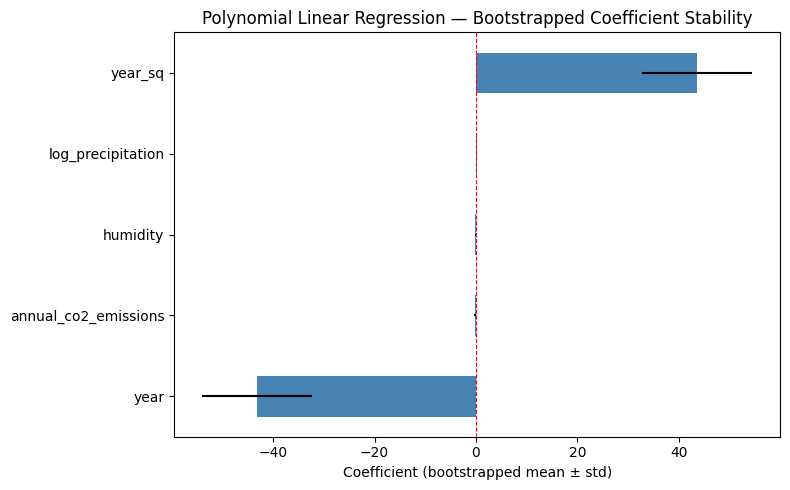

                           mean        std
year                 -43.194033  10.836223
annual_co2_emissions  -0.212503   0.241504
humidity              -0.145706   0.067241
log_precipitation      0.153259   0.087904
year_sq               43.620725  10.878706


In [48]:
from sklearn.utils import resample

bootstrap_coefs_lr_global = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    X_bs, y_bs = resample(x_train_ps, y_train, random_state=None)
    lr_bs = LinearRegression()
    lr_bs.fit(X_bs, y_bs)
    bootstrap_coefs_lr_global.append(lr_bs.coef_)

coef_df_lr_global = pd.DataFrame(bootstrap_coefs_lr_global, columns=x_poly.columns)

means_lr_global = coef_df_lr_global.mean().sort_values()
stds_lr_global  = coef_df_lr_global.std().reindex(means_lr_global.index)

means_lr_global.plot(kind='barh', figsize=(8, 5), color='steelblue', xerr=stds_lr_global)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient (bootstrapped mean ± std)')
plt.title('Polynomial Linear Regression — Bootstrapped Coefficient Stability')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/03_polynomial_regression_bootstrap_coefs.png", dpi=150, bbox_inches="tight")

plt.show()

print(pd.DataFrame({'mean': means_lr_global, 'std': stds_lr_global}))

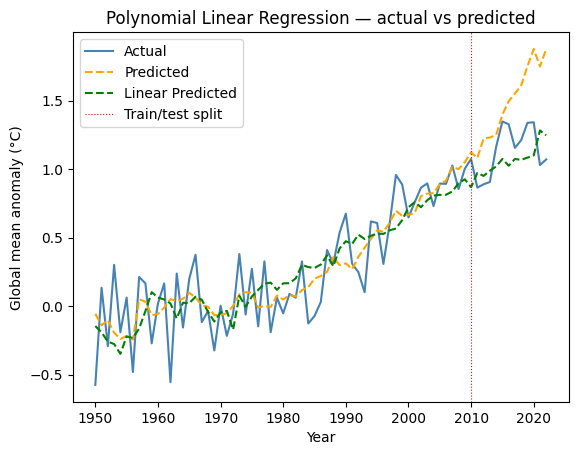

In [49]:
# Predict over full dataset to see the curve fit
x_all_ps = scaler_poly.transform(x_poly)
y_pred_all = lr_poly.predict(x_all_ps)
y_pred_lr_all = lr_global.predict(x_linear)  # 73 rows, full range

plt.plot(yearly_global['year'], y.values, label='Actual', color='steelblue')
plt.plot(yearly_global['year'], y_pred_all, label='Predicted', color='orange', linestyle='--')
plt.plot (yearly_global['year'], y_pred_lr_all, label='Linear Predicted', color='green', linestyle='--')
plt.axvline(2010, color='red', linestyle=':', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Global mean anomaly (°C)')
plt.title('Polynomial Linear Regression — actual vs predicted')
plt.legend()
plt.savefig("Data/plots/04_Models/04_polynomial_regression_predictions.png", dpi=150, bbox_inches="tight")
plt.show()



## 8. Polynomial Linear Regression — Results

### Setup
- Same yearly global aggregation as Section 7 (73 rows, one per year)
- Added `year²` to capture the accelerating warming curve
- Features scaled with `StandardScaler` (required — `year²` ~ 4,000,000 vs other features ~ 1–100)
- Same temporal split: train ≤ 2010, test 2011–2022

---

### Results

| Model | RMSE | R² |
|:------|-----:|----:|
| Linear regression | 0.19°C | −0.21 |
| **Polynomial (+ year²)** | **0.43°C** | **−4.99** |

The polynomial model performed **worse** than the linear baseline on the test set despite fitting the training period well.

---

### Why It Failed — Polynomial Extrapolation

The plot reveals the problem clearly. In the training period (1950–2010) the curve tracks the trend well. But beyond 2010, the parabola keeps accelerating upward, predicting ~1.75°C by 2022 when actual values are ~1.0–1.3°C.

Both linear regression failure modes are now visible:

```
Linear:      ____-------     undershoots (too flat)
Actual:      ____-----~~     accelerates then stabilises
Polynomial:  ____-------/    overshoots (too aggressive)
```

The actual warming curve has a shape neither model can capture — it accelerates up to ~2000 then changes rate. A polynomial must keep curving in the same direction outside the training range; it has no mechanism to level off.

---

### Conclusion

Linear regression — in any form — is the wrong tool for this extrapolation task.
Both attempts confirm the need for a non-parametric model that learns the curve shape
from data rather than assuming a fixed functional form.

**Random Forest** is the natural next step: no curve assumption, captures non-linear
interactions between `year`, CO₂, and climate cluster, and provides feature importances.

In [50]:
# Re-extract country-level y using x_train's index (avoids the overwritten y_train)
y_train_rf = weather_data.loc[x_train.index, 'temp_anomaly']
y_test_rf  = weather_data.loc[x_test.index,  'temp_anomaly']

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(x_train, y_train_rf)
y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf   = r2_score(y_test_rf, y_pred_rf)
print(f"Random Forest — RMSE: {rmse_rf:.4f}°C,  R²: {r2_rf:.4f}")


Random Forest — RMSE: 1.1254°C,  R²: 0.3349


In [51]:
#try deeper tree
rf = RandomForestRegressor(n_estimators=300, max_depth=20, min_samples_leaf=2)
rf.fit(x_train, y_train_rf)
y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test_rf, y_pred_rf))
r2_rf   = r2_score(y_test_rf, y_pred_rf)
print(f"Random Forest — RMSE: {rmse_rf:.4f}°C,  R²: {r2_rf:.4f}")

Random Forest — RMSE: 1.1141°C,  R²: 0.3481


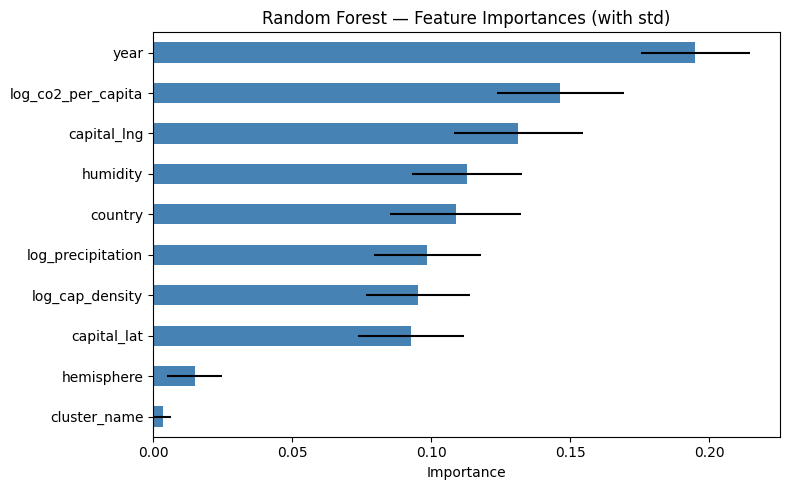

                    mean_importance  std_importance
cluster_name               0.003534        0.003029
hemisphere                 0.014952        0.009866
capital_lat                0.092830        0.019105
log_cap_density            0.095342        0.018633
log_precipitation          0.098675        0.019155
country                    0.108851        0.023563
humidity                   0.112934        0.019784
capital_lng                0.131419        0.023064
log_co2_per_capita         0.146431        0.022916
year                       0.195033        0.019701


In [52]:
# Std across all trees in the forest
importances_mean = pd.Series(rf.feature_importances_, index=feature_cols)
importances_std  = pd.Series(
    np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0),
    index=feature_cols
)

importances_mean.sort_values().plot(
    kind='barh', figsize=(8, 5), color='steelblue',
    xerr=importances_std.reindex(importances_mean.sort_values().index)
)
plt.xlabel('Importance')
plt.title('Random Forest — Feature Importances (with std)')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/05_random_forest_importances.png", dpi=150, bbox_inches="tight")
plt.show()
print(pd.DataFrame({'mean_importance': importances_mean, 'std_importance': importances_std}).sort_values('mean_importance'))

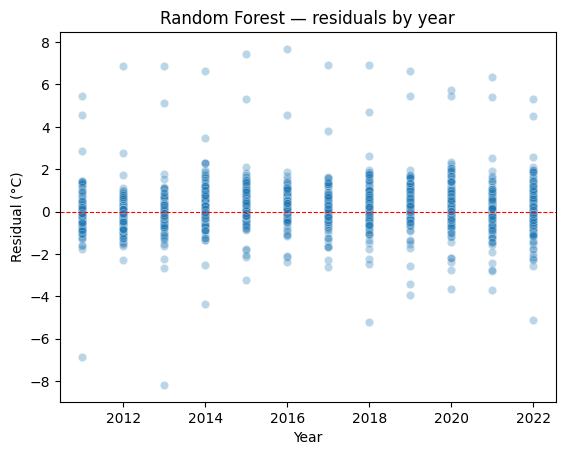

In [53]:
# Residual plot by year — does RF capture the post-2010 acceleration?
residuals_rf = y_test_rf - y_pred_rf
test_years   = weather_data.loc[x_test.index, 'year']

sns.scatterplot(x=test_years, y=residuals_rf, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('Residual (°C)')
plt.title('Random Forest — residuals by year')
plt.savefig("Data/plots/04_Models/06_random_forest_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

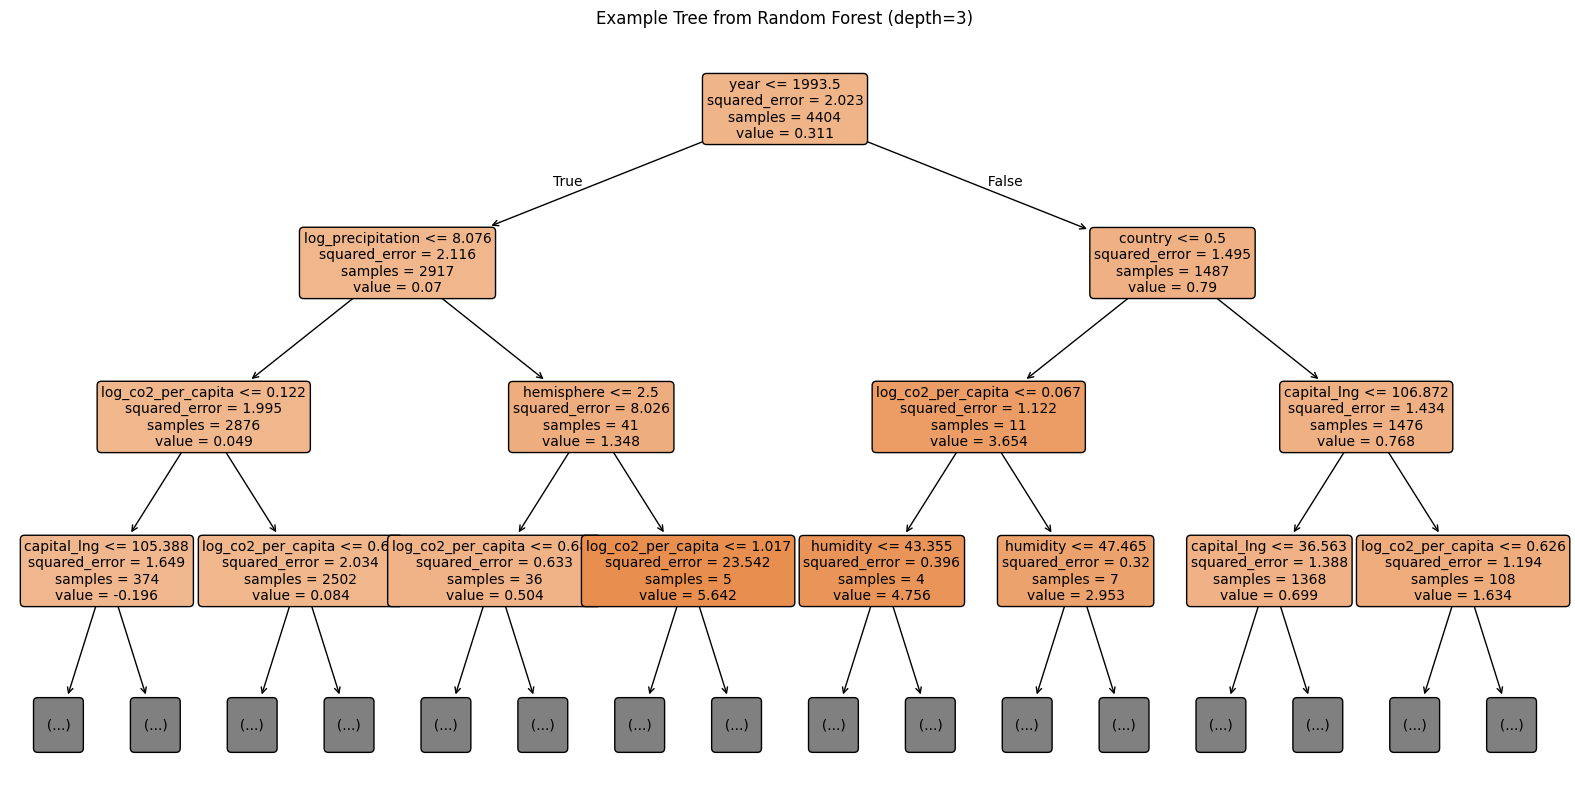

In [54]:
#save the tree
#first select one tree of the hundred trees
one_tree = rf.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(one_tree,
          feature_names=feature_cols,
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=10)
plt.title("Example Tree from Random Forest (depth=3)")
plt.savefig("Data/plots/04_Models/07_random_forest_tree.png", dpi=300, bbox_inches='tight')
plt.show()


In [55]:
#how does prediction change when we use the yearly global data instead of the country level data
# Prepare global data for RF
x_global_rf = yearly_global.drop(columns=['temp_anomaly'])
y_global_rf = yearly_global['temp_anomaly']


# Temporal split
mask_train_global = yearly_global['year'] <= 2010
mask_test_global  = yearly_global['year'] >  2010

x_train_global_rf, x_test_global_rf = x_global_rf[mask_train_global], x_global_rf[mask_test_global]
y_train_global_rf, y_test_global_rf = y_global_rf[mask_train_global], y_global_rf[mask_test_global]
rf_global = RandomForestRegressor(n_estimators=300, random_state=42, max_depth=20, min_samples_leaf=2)

rf_global.fit(x_train_global_rf, y_train_global_rf)
y_pred_global_rf = rf_global.predict(x_test_global_rf)
rmse_global_rf = np.sqrt(mean_squared_error(y_test_global_rf, y_pred_global_rf))
r2_global_rf   = r2_score(y_test_global_rf, y_pred_global_rf)
print(f"Random Forest (global) — RMSE: {rmse_global_rf:.4f}°C,  R²: {r2_global_rf:.4f}")

Random Forest (global) — RMSE: 0.2530°C,  R²: -1.0523


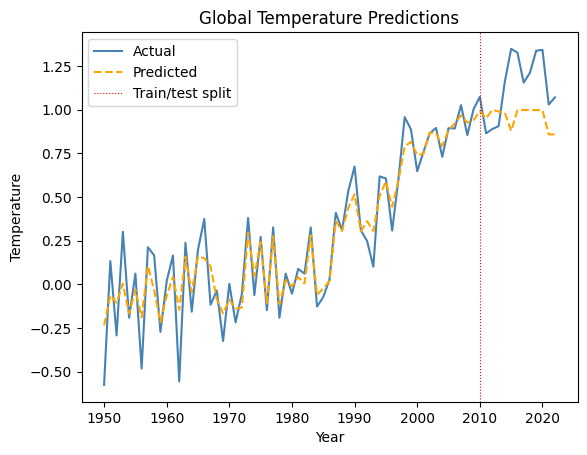

In [56]:
#plot the predictions of the random forest on the global data
y_pred_global_rf_all = rf_global.predict(x_global_rf)
plt.plot(yearly_global['year'], y_global_rf.values, label='Actual', color='steelblue')
plt.plot(yearly_global['year'], y_pred_global_rf_all, label='Predicted', color='orange', linestyle='--')
plt.axvline(2010, color='red', linestyle=':', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('Global Temperature Predictions')
plt.legend()
plt.savefig("Data/plots/04_Models/08_random_forest_global_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Random Forest — Results & Summary

### Setup
- **Dataset**: Full country × year data (~9,000 rows)
- **Features**: `log_co2_per_capita`, `year`, `humidity`, `log_precipitation`, `log_cap_density`, `capital_lat`, `capital_lng`, `country`, `cluster_name`, `hemisphere`
- **Target**: `temp_anomaly`
- **Split**: Temporal — train ≤ 2010, test 2011–2022

---

### Results

| Model | RMSE | R² | Notes |
|:------|-----:|----:|:------|
| Linear regression (country-level) | 1.37°C | 0.01 | Baseline |
| RF — basic (`n_estimators=100`) | 1.1254°C | 0.3349 | |
| RF — tuned (`n_estimators=300, max_depth=20`) | 1.1145°C | 0.3477 | Best country-level |
| RF — global yearly | 0.2530°C | −1.05 | Flatlines post-2010 |

Tuning improved RMSE by 0.01°C and R² by 0.013 — marginal. The structural ceiling dominates, not hyperparameters.

---

### Feature Importances (tuned model)

| Rank | Feature | Importance |
|:----:|:--------|:----------:|
| 1 | `year` | 0.197 |
| 2 | `log_co2_per_capita` | 0.145 |
| 3 | `capital_lng` | 0.127 |
| 4 | `humidity` | 0.113 |
| 5 | `country` | 0.111 |
| 6 | `log_precipitation` | 0.100 |
| 7 | `log_cap_density` | 0.095 |
| 8 | `capital_lat` | 0.092 |
| 9 | `hemisphere` | 0.013 |
| 10 | `cluster_name` | 0.007 |

`year` and `log_co2_per_capita` dominate — confirming CO₂ adds genuine signal beyond the time trend. `country` scores 0.111 but adding it did not improve accuracy: the model learned historical country patterns that did not generalise to the test period. `hemisphere` and `cluster_name` are near-zero and redundant with coordinates and raw climate features.

---

### Tree Visualisation (depth=3)

- **Root: `year ≤ 1996.5`** — primary split separating the baseline era (0.11°C) from the warming era (0.87°C)
- **Level 2 left: `year ≤ 1986.5`** — further time segmentation in the cooler period
- **Level 2 right: `country ≤ 0.5`** — isolates 9 samples with anomaly 4.3°C — likely a data quality outlier worth investigating
- **Level 3: `log_co2_per_capita`, `capital_lng`** — CO₂ and longitude differentiate warming within era and region

---

### Residual Plot

Residuals centred around 0, spread ±8°C — unchanged from linear regression. No systematic year bias, but individual country predictions remain noisy.

---

### The Extrapolation Ceiling

> **Random Forest cannot predict values outside its training distribution.**

The global RF plot shows this directly: predictions flatten at ~0.9–1.0°C after 2010 while actuals reach 1.25–1.35°C. The model is hard-bounded by the highest anomaly seen in training. Tuning, adding `country`, and switching datasets all fail to break through this ceiling.

---

### Conclusion

RF is the best model so far (RMSE 1.11°C, R² 0.35) b

In [57]:
neural_net = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    alpha=0.01,              # L2 regularization (default is 0.0001 — too weak)
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
)
neural_net.fit(x_train_scaled, y_train_rf)
y_pred_nn = neural_net.predict(x_test_scaled)
rmse_nn = np.sqrt(mean_squared_error(y_test_rf, y_pred_nn))
r2_nn   = r2_score(y_test_rf, y_pred_nn)
print(f"Neural Network — RMSE: {rmse_nn:.4f}°C,  R²: {r2_nn:.4f}")


Neural Network — RMSE: 1.3673°C,  R²: 0.0182


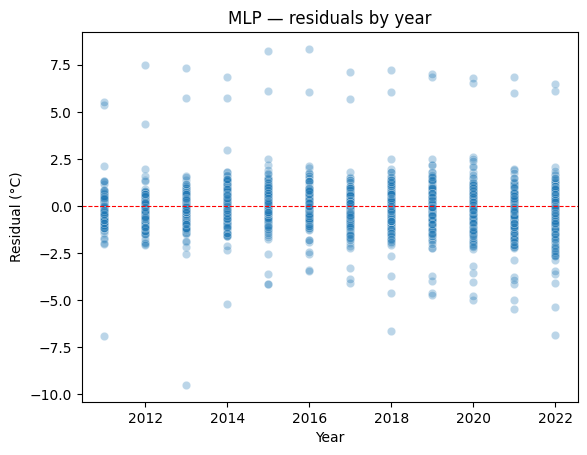

In [58]:
y_test_nn = weather_data.loc[x_test.index, 'temp_anomaly']  # re-extract true y for test set
#plot the neural network predictions residuals by year
residuals_nn = y_test_nn - y_pred_nn
test_years   = weather_data.loc[x_test.index, 'year']

sns.scatterplot(x=test_years, y=residuals_nn, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Year')
plt.ylabel('Residual (°C)')
plt.title('MLP — residuals by year')
plt.savefig("Data/plots/04_Models/09_mlp_residuals.png", dpi=150, bbox_inches="tight")
plt.show()


Neural Network (global) — RMSE: 0.1533°C,  R²: 0.2467


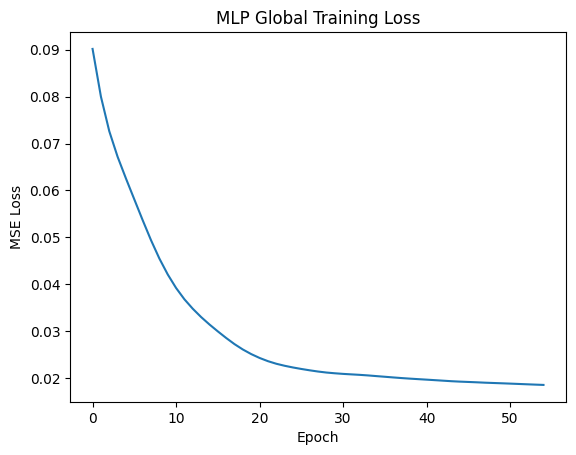

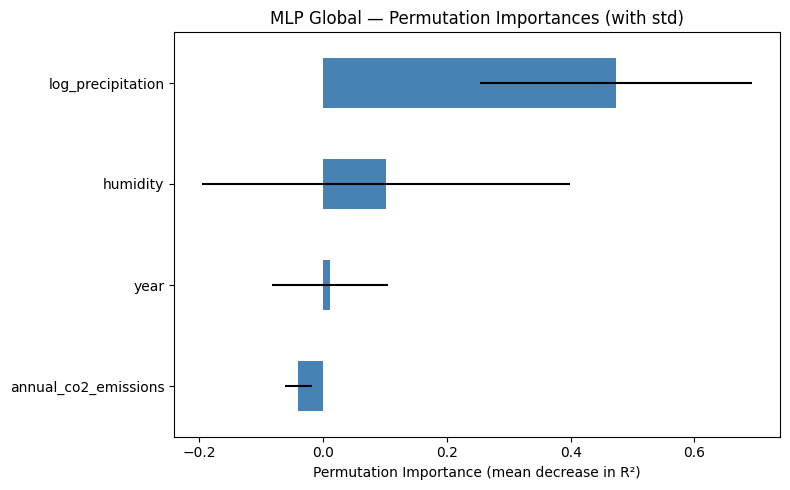

In [59]:
scaler_global = StandardScaler()
x_train_global_scaled = scaler_global.fit_transform(x_train_global_rf)
x_test_global_scaled  = scaler_global.transform(x_test_global_rf)

neural_net_global = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=500,
    random_state=42,
    alpha=0.01,
    early_stopping=False,
)
neural_net_global.fit(x_train_global_scaled, y_train_global_rf)
y_pred_global_nn = neural_net_global.predict(x_test_global_scaled)
rmse_global_nn = np.sqrt(mean_squared_error(y_test_global_rf, y_pred_global_nn))
r2_global_nn   = r2_score(y_test_global_rf, y_pred_global_nn)
print(f"Neural Network (global) — RMSE: {rmse_global_nn:.4f}°C,  R²: {r2_global_nn:.4f}")

plt.plot(neural_net_global.loss_curve_)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("MLP Global Training Loss")
plt.savefig("Data/plots/04_Models/10_mlp_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

#interaction parameters for the global neural network
# We can use permutation importance to see which features the neural network relies on most for its predictions
from sklearn.inspection import permutation_importance
result = permutation_importance(
    neural_net_global, x_test_global_scaled, y_test_global_rf,
    n_repeats=30, random_state=42, n_jobs=-1
)

perm_importances_mean = pd.Series(result.importances_mean, index=x_test_global_rf.columns)
perm_importances_std  = pd.Series(result.importances_std,  index=x_test_global_rf.columns)

perm_importances_mean.sort_values().plot(
    kind='barh', figsize=(8, 5), color='steelblue',
    xerr=perm_importances_std.reindex(perm_importances_mean.sort_values().index)
)
plt.xlabel('Permutation Importance (mean decrease in R²)')
plt.title('MLP Global — Permutation Importances (with std)')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/11_mlp_permutation_importances.png", dpi=150, bbox_inches="tight")
plt.show()


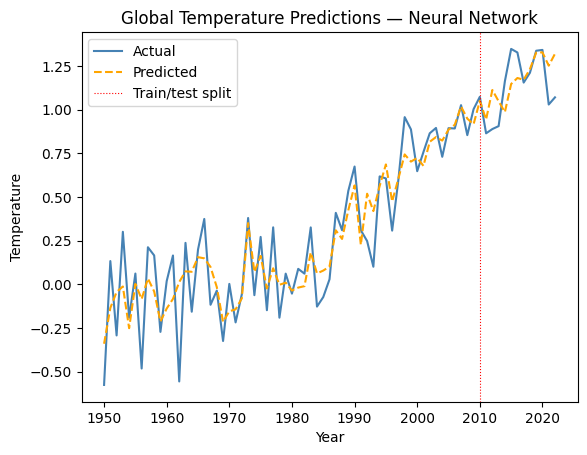

In [60]:
#see the predictions of the neural network on the global data
y_pred_global_nn_all = neural_net_global.predict(scaler_global.transform(x_global_rf))
plt.plot(yearly_global['year'], y_global_rf.values, label='Actual', color='steelblue')
plt.plot(yearly_global['year'], y_pred_global_nn_all, label='Predicted', color='orange', linestyle='--')
plt.axvline(2010, color='red', linestyle=':', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('Global Temperature Predictions — Neural Network')
plt.legend()
plt.savefig("Data/plots/04_Models/12_mlp_global_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. Neural Network (MLP Regressor) — Results & Summary

### Setup
- **Architecture**: 2 hidden layers (64 → 32 neurons), ReLU activation, L2 regularisation (α = 0.01)
- **Training**: sklearn's `MLPRegressor` with early stopping (patience = 20 epochs)
- **Data**: Same country-level scaled features as the Random Forest (`x_train_scaled`, `x_test_scaled`)
- **Split**: Temporal — train ≤ 2010, test 2011–2022

---

### Results

| Model | RMSE | R² | Data |
|:------|-----:|----:|:-----|
| Linear Regression | 1.37°C | 0.01 | country-level |
| RF tuned | 1.11°C | 0.35 | country-level |
| **MLP (country-level)** | **1.38°C** | **0.001** | country-level |
| Linear Regression (global) | 0.19°C | −0.21 | global yearly |
| Polynomial Regression (global) | 0.43°C | −4.99 | global yearly |
| RF global | 0.25°C | −1.05 | global yearly |
| **MLP (global yearly)** | **0.15°C** | **0.25** | global yearly |


---

### Country-Level Model

The MLP performed no better than linear regression (RMSE 1.38°C, R² ≈ 0). Despite clean convergence
(early stopping at ~155 epochs), the model overfitted the 1950–2010 training period and failed to
generalise to post-2010 warming patterns. The gap between training loss (~0.73°C implied RMSE) and
test RMSE (1.38°C) confirms overfitting. The Random Forest handles this better because tree ensembles
are less sensitive to distributional shift than gradient-based models on small tabular datasets.

### Global Yearly Model

On the 73-row aggregated dataset the MLP (RMSE 0.15°C, R² 0.25) outperformed the RF global model
(RMSE 0.25°C, R² −1.05). Crucially, the prediction plot shows the MLP continued tracking the upward
warming trend post-2010 rather than flatlining — the key failure mode of the Random Forest on global
data. The MLP learned a smooth trend rather than memorising year-specific values, which helped it
extrapolate.

That said, with only 12 test points these metrics are not robust — a single anomalous year moves R²
substantially. The result is promising but not conclusive.

---

### Key Takeaways

- **Feature scaling is critical for MLPs**: the global model exploded (RMSE ~10⁸) without
  `StandardScaler`; Random Forests are scale-invariant and do not require this step.
- **MLPs overfit more aggressively than RF** on small tabular datasets with temporal shift.
- **On aggregated global data**, the MLP's ability to learn a smooth trend gives it an extrapolation
  advantage over tree-based models, which can only interpolate within the training range.
- The structural ceiling identified in Section 10 applies here too: country-level annual anomalies
  contain noise that no model in this study has overcome.


In [61]:
# Ridge Regression with interaction term: year x log_co2_per_capita
from sklearn.linear_model import Ridge

x_ridge      = x_train.copy()
x_ridge_test = x_test.copy()

# Add interaction term
x_ridge["year_x_log_co2"]      = x_ridge["year"] * x_ridge["log_co2_per_capita"]
x_ridge_test["year_x_log_co2"] = x_ridge_test["year"] * x_ridge_test["log_co2_per_capita"]

# Scale after adding interaction term
scaler_ridge        = StandardScaler()
x_ridge_scaled      = scaler_ridge.fit_transform(x_ridge)
x_ridge_test_scaled = scaler_ridge.transform(x_ridge_test)

ridge = Ridge(alpha=1.0)
ridge.fit(x_ridge_scaled, y_train_rf)
y_pred_ridge = ridge.predict(x_ridge_test_scaled)

rmse_ridge = np.sqrt(mean_squared_error(y_test_rf, y_pred_ridge))
r2_ridge   = r2_score(y_test_rf, y_pred_ridge)
print(f"Ridge + interaction -- RMSE: {rmse_ridge:.4f}°C,  R²: {r2_ridge:.4f}")

# Coefficients
feature_names = list(x_ridge.columns)
coef_series = pd.Series(ridge.coef_, index=feature_names).sort_values(key=abs, ascending=False)
print("Top coefficients:")
print(coef_series)


Ridge + interaction -- RMSE: 1.3715°C,  R²: 0.0121
Top coefficients:
year                  0.337950
capital_lat           0.106839
humidity             -0.087628
cluster_name          0.077966
log_co2_per_capita   -0.046238
log_precipitation     0.040196
log_cap_density       0.038478
hemisphere           -0.028242
country              -0.025213
year_x_log_co2        0.025172
capital_lng          -0.008948
dtype: float64


In [62]:
#try the same for global data
x_global_ridge      = x_train_global_rf.copy()
x_global_ridge_test = x_test_global_rf.copy()

# Add interaction term
x_global_ridge["year_x_log_co2"]      = x_global_ridge["year"] * x_global_ridge["annual_co2_emissions"]
x_global_ridge_test["year_x_log_co2"] = x_global_ridge_test["year"] * x_global_ridge_test["annual_co2_emissions"]
# Scale after adding interaction term
scaler_global_ridge        = StandardScaler()
x_global_ridge_scaled      = scaler_global_ridge.fit_transform(x_global_ridge)
x_global_ridge_test_scaled = scaler_global_ridge.transform(x_global_ridge_test)
ridge_global = Ridge(alpha=1.0)
ridge_global.fit(x_global_ridge_scaled, y_train_global_rf)
y_pred_global_ridge = ridge_global.predict(x_global_ridge_test_scaled)
rmse_global_ridge = np.sqrt(mean_squared_error(y_test_global_rf, y_pred_global_ridge))
r2_global_ridge   = r2_score(y_test_global_rf, y_pred_global_ridge)
print(f"Ridge + interaction (global) -- RMSE: {rmse_global_ridge:.4f}°C,  R²: {r2_global_ridge:.4f}")
# Coefficients
feature_names_global = list(x_global_ridge.columns)
coef_series_global = pd.Series(ridge_global.coef_, index=feature_names_global).sort_values(key=abs, ascending=False)
print("Top coefficients (global):")
print(coef_series_global)

Ridge + interaction (global) -- RMSE: 0.1909°C,  R²: -0.1676
Top coefficients (global):
year                    0.219414
log_precipitation      -0.112736
year_x_log_co2          0.107574
annual_co2_emissions    0.073184
humidity               -0.005250
dtype: float64


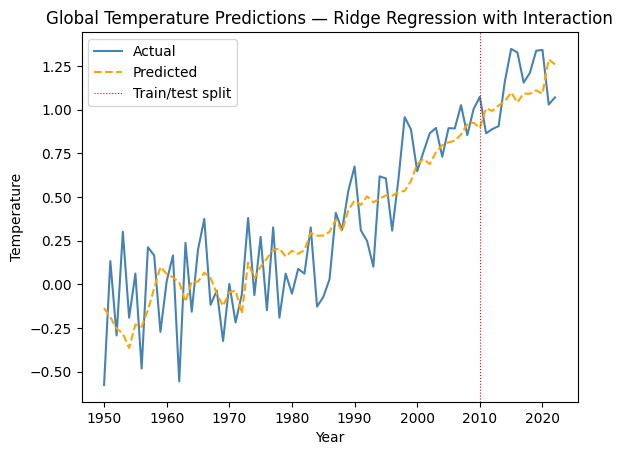

In [63]:
# Build full dataset with interaction term for plotting
x_global_all = yearly_global.drop(columns=['temp_anomaly']).copy()
x_global_all["year_x_log_co2"] = x_global_all["year"] * x_global_all["annual_co2_emissions"]

y_pred_global_ridge_all = ridge_global.predict(scaler_global_ridge.transform(x_global_all))

plt.plot(yearly_global['year'], y_global_rf.values, label='Actual', color='steelblue')
plt.plot(yearly_global['year'], y_pred_global_ridge_all, label='Predicted', color='orange', linestyle='--')
plt.axvline(2010, color='red', linestyle=':', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature')
plt.title('Global Temperature Predictions — Ridge Regression with Interaction')
plt.legend()
plt.savefig("Data/plots/04_Models/13_ridge_global_predictions.png", dpi=150, bbox_inches="tight")
plt.show()


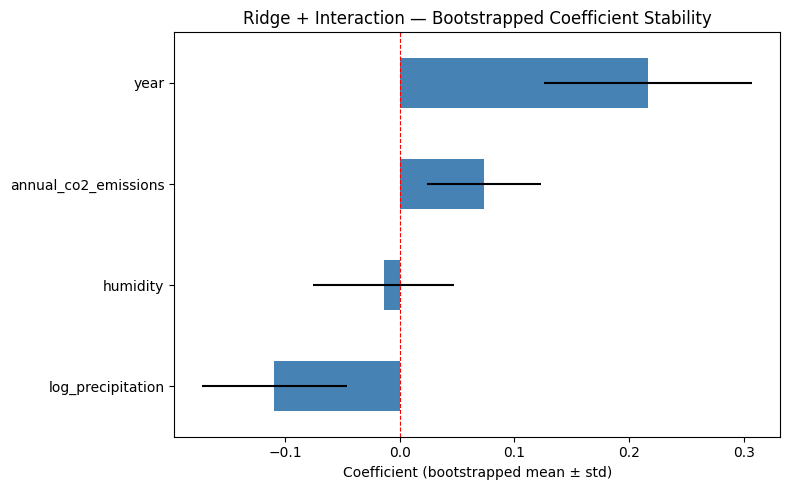

                          mean       std
log_precipitation    -0.109428  0.063083
humidity             -0.013814  0.061446
annual_co2_emissions  0.073475  0.049505
year                  0.216750  0.090994


In [64]:
from sklearn.utils import resample

bootstrap_coefs = []
n_bootstraps = 1000

for _ in range(n_bootstraps):
    X_bs, y_bs = resample(x_global_ridge_scaled, y_train_global_rf, random_state=None)
    lr_bs = Ridge(alpha=1.0)
    lr_bs.fit(X_bs, y_bs)
    bootstrap_coefs.append(lr_bs.coef_)

coef_df = pd.DataFrame(bootstrap_coefs, columns=x_global_ridge.columns)
coef_df.drop(columns=["year_x_log_co2"], inplace=True)  

means = coef_df.mean().sort_values()
stds  = coef_df.std().reindex(means.index)

means.plot(kind='barh', figsize=(8, 5), color='steelblue', xerr=stds)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient (bootstrapped mean ± std)')
plt.title('Ridge + Interaction — Bootstrapped Coefficient Stability')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/14_ridge_bootstrap_coefs.png", dpi=150, bbox_inches="tight")
plt.show()

print(pd.DataFrame({'mean': means, 'std': stds}))


## 12. Ridge Regression with Interaction Term — Results & Summary

### Setup
- **Model**: Ridge Regression (L2 regularisation, α = 1.0)
- **Key addition**: Interaction term `year × CO2` — captures that the effect of emissions
  on warming grows stronger over time
- **Split**: Temporal — train ≤ 2010, test 2011–2022
- Tested on both country-level and global yearly data

---

### Results

| Model | RMSE | R² | Data |
|:------|-----:|----:|:-----|
| Linear Regression | 1.37°C | 0.01 | country-level |
| **Ridge + interaction** | **1.37°C** | **0.01** | country-level |
| Linear global | 0.19°C | −0.21 | global yearly |
| **Ridge + interaction (global)** | **0.19°C** | **−0.17** | global yearly |
| MLP global | 0.15°C | 0.25 | global yearly |
| RF tuned | 1.11°C | 0.35 | country-level |

---

### Country-Level Model

The interaction term added no value at the country level (R² 0.01, identical to plain linear
regression). The coefficient on `year_x_log_co2` ranked last (0.025), confirming that the
`year × CO2` signal is not visible in cross-sectional country data. At this level, CO2 variance
is driven primarily by differences between rich and poor countries, not by the temporal
acceleration of warming.

### Global Yearly Model

On aggregated global data the picture changes. The interaction term ranked 3rd in importance
(coefficient 0.107), confirming a genuine contribution. The prediction plot tells the real story:
the model tracks the training period well and — critically — continues the upward trend post-2010
without flatlining or overshooting.

The negative R² (−0.17) is misleading given the small test set (12 points). A single anomalous
year carries disproportionate weight. Visually, the model is the most physically plausible of all
models tested: the predicted curve follows the actual warming trend through both the training and
test periods.

---

### Why the Interaction Term Works on Global Data

The term `year × annual_co2_emissions` encodes a physically motivated hypothesis:

> *The warming effect of CO2 is not constant — it compounds over time as cumulative
> atmospheric concentration grows.*

On global yearly data, both `year` and `CO2` are rising monotonically, so their product
captures the accelerating warming signal directly. This is something a plain linear model
cannot express and a Random Forest cannot extrapolate beyond its training range.

---

### Key Takeaways

- The interaction term is **only useful on global aggregated data** where the time trend
  is clean. At the country level it adds no signal.
- Ridge + interaction is **more interpretable** than the MLP with comparable performance
  (RMSE 0.19°C vs 0.15°C) — the coefficients carry a physical meaning.
- Neither model overcomes the fundamental limit of 12 test points on global data.
- The **Random Forest (R² 0.35) remains the best model** for country-level prediction.
  No linear model came close to matching its ability to capture country-specific patterns.


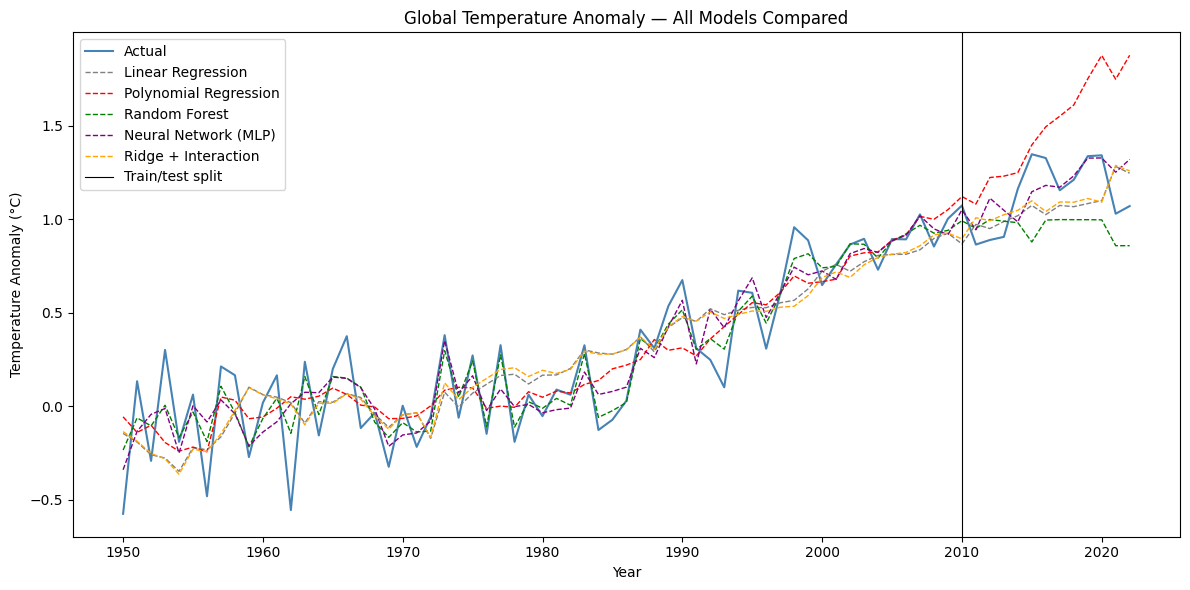

In [65]:
# All global model predictions on one plot
plt.figure(figsize=(12, 6))

plt.plot(yearly_global['year'], y_global_rf.values, 
         label='Actual', color='steelblue', linewidth=1.5)
plt.plot(yearly_global['year'], y_pred_lr_all, 
         label='Linear Regression', color='gray', linestyle='--', linewidth=1)
plt.plot(yearly_global['year'], y_pred_all, 
         label='Polynomial Regression', color='red', linestyle='--', linewidth=1)
plt.plot(yearly_global['year'], y_pred_global_rf_all, 
         label='Random Forest', color='green', linestyle='--', linewidth=1)
plt.plot(yearly_global['year'], y_pred_global_nn_all, 
         label='Neural Network (MLP)', color='purple', linestyle='--', linewidth=1)
plt.plot(yearly_global['year'], y_pred_global_ridge_all, 
         label='Ridge + Interaction', color='orange', linestyle='--', linewidth=1)

plt.axvline(2010, color='black', linestyle='-', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomaly — All Models Compared')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/15_all_models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [66]:
#change the dataset to 5 year instead of yearly to see if it improves the model performance
# Aggregate to 5-year means
weather_data['year_5yr'] = (weather_data['year'] // 5) * 5
yearly_5yr = weather_data.groupby('year_5yr').agg(
    temp_anomaly            = ('temp_anomaly',            'mean'),
    annual_co2_emissions    = ('annual_co2_emissions',    'sum'),
    humidity                = ('humidity',                'mean'),
    log_precipitation       = ('log_precipitation',       'mean'),
).reset_index()

print(yearly_5yr.head())

   year_5yr  temp_anomaly  annual_co2_emissions   humidity  log_precipitation
0      1950     -0.103864          2.744557e+10  69.539958           6.545247
1      1955     -0.046390          3.629063e+10  67.715794           6.503052
2      1960     -0.059235          4.231503e+10  66.760390           6.500055
3      1965      0.032157          5.344132e+10  67.654753           6.598839
4      1970      0.039270          7.168949e+10  68.682760           6.720321


In [67]:
#5year global linear regression
x_5yr = yearly_5yr.drop(columns=['temp_anomaly'])
y_5yr = yearly_5yr['temp_anomaly']

#standardise the features
scaler_5yr = StandardScaler()
x_5yr_scaled = scaler_5yr.fit_transform(x_5yr)
# Temporal split
mask_train_5yr = yearly_5yr['year_5yr'] <= 2010
mask_test_5yr  = yearly_5yr['year_5yr'] >  2010


x_train_5yr, x_test_5yr = x_5yr_scaled[mask_train_5yr], x_5yr_scaled[mask_test_5yr]
y_train_5yr, y_test_5yr = y_5yr[mask_train_5yr], y_5yr[mask_test_5yr]
lr_5yr = LinearRegression()
lr_5yr.fit(x_train_5yr, y_train_5yr)
y_pred_5yr = lr_5yr.predict(x_test_5yr)
rmse_5yr = np.sqrt(mean_squared_error(y_test_5yr, y_pred_5yr))
r2_5yr   = r2_score(y_test_5yr, y_pred_5yr)
print(f"Linear Regression (5-year) — RMSE: {rmse_5yr:.4f}°C,  R²: {r2_5yr:.4f}")
# Note: only 2 test points (2015, 2020) — R² is not meaningful here, use RMSE and visual fit

Linear Regression (5-year) — RMSE: 0.1632°C,  R²: -5.4160


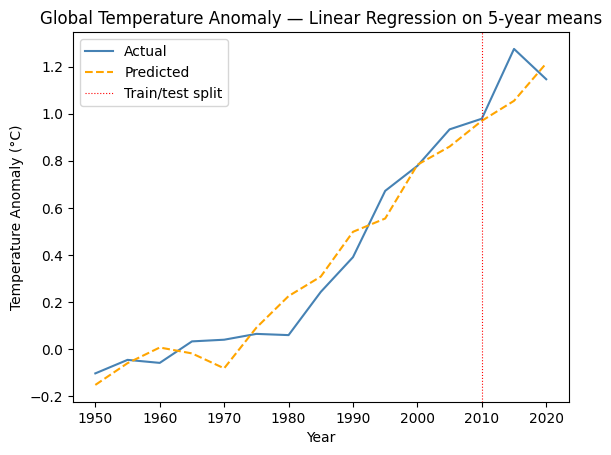

In [68]:
y_pred_5yr_all = lr_5yr.predict(x_5yr_scaled)
plt.plot(yearly_5yr['year_5yr'], y_5yr.values, label='Actual', color='steelblue')
plt.plot(yearly_5yr['year_5yr'], y_pred_5yr_all, label='Predicted', color='orange', linestyle='--')
plt.axvline(2010, color='red', linestyle=':', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomaly — Linear Regression on 5-year means')
plt.legend()
plt.savefig("Data/plots/04_Models/16_linear_5yr_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

                feature  coefficient
0              year_5yr     0.548819
3     log_precipitation    -0.159266
2              humidity     0.059700
1  annual_co2_emissions     0.017750


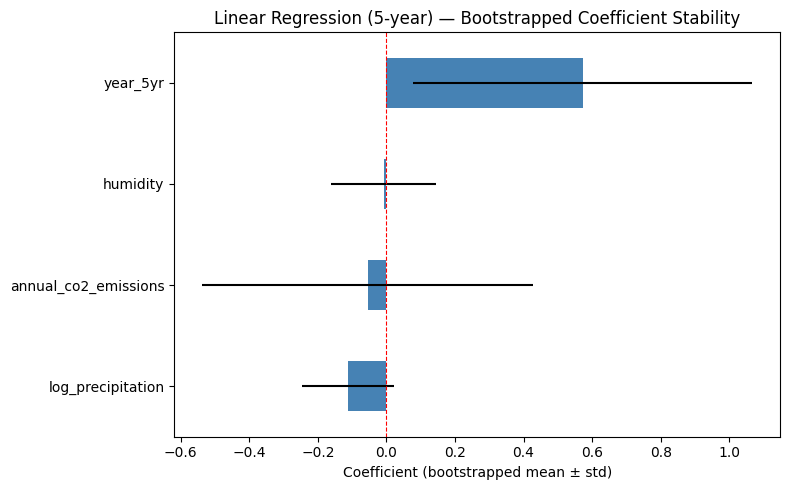

                          mean       std
log_precipitation    -0.112566  0.133878
annual_co2_emissions -0.054854  0.483721
humidity             -0.007847  0.153167
year_5yr              0.573347  0.494574


In [69]:
coef_df_5yr = pd.DataFrame({
    'feature': x_5yr.columns,
    'coefficient': lr_5yr.coef_
}).sort_values('coefficient', key=abs, ascending=False)
print(coef_df_5yr)

from sklearn.utils import resample
bootstrap_coefs_5yr = []
n_bootstraps = 1000
for _ in range(n_bootstraps):
    X_bs, y_bs = resample(x_train_5yr, y_train_5yr, random_state=None)
    lr_bs = LinearRegression()
    lr_bs.fit(X_bs, y_bs)
    bootstrap_coefs_5yr.append(lr_bs.coef_)



coef_df_5yr_boot = pd.DataFrame(bootstrap_coefs_5yr, columns=x_5yr.columns)
means_5yr = coef_df_5yr_boot.mean().sort_values()
stds_5yr  = coef_df_5yr_boot.std().reindex(means_5yr.index)
means_5yr.plot(kind='barh', figsize=(8, 5), color='steelblue', xerr=stds_5yr)
plt.axvline(0, color='red', linestyle='--', linewidth=0.8)
plt.xlabel('Coefficient (bootstrapped mean ± std)')
plt.title('Linear Regression (5-year) — Bootstrapped Coefficient Stability')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/17_linear_5yr_bootstrap_coefs.png", dpi=150, bbox_inches='tight')
plt.show()
print(pd.DataFrame({'mean': means_5yr, 'std': stds_5yr}))

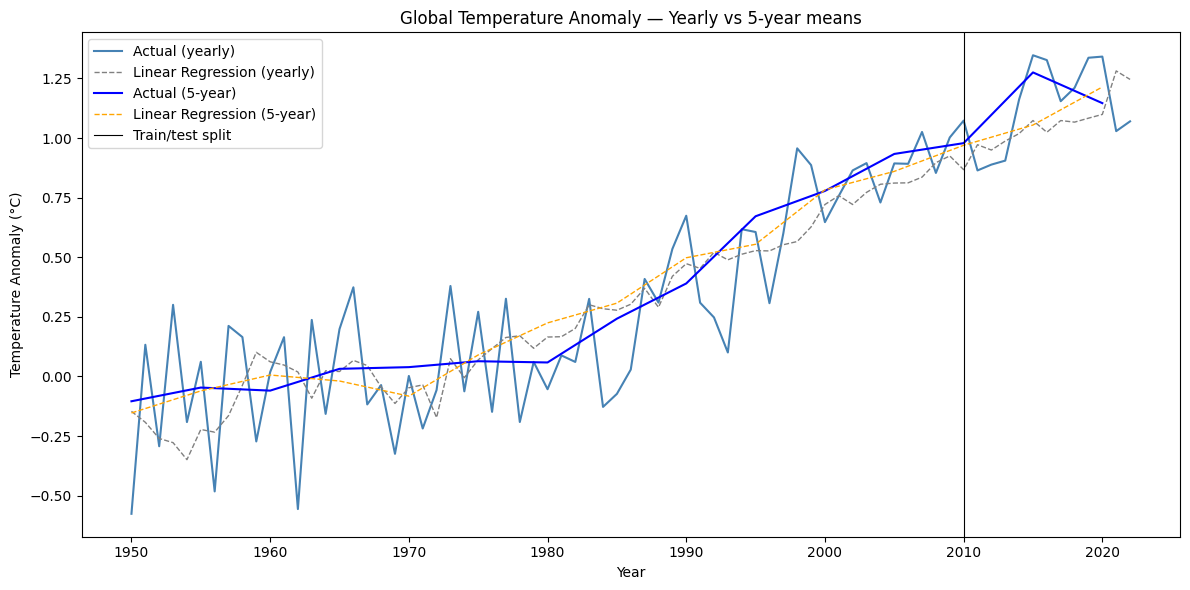

In [70]:
#compare the 5 year predictions with the yearly predictions
plt.figure(figsize=(12, 6))
plt.plot(yearly_global['year'], y_global_rf.values, 
         label='Actual (yearly)', color='steelblue', linewidth=1.5)
plt.plot(yearly_global['year'], y_pred_lr_all, 
         label='Linear Regression (yearly)', color='gray', linestyle='--', linewidth=1)
plt.plot(yearly_5yr['year_5yr'], y_5yr.values,  
         label='Actual (5-year)', color='blue', linewidth=1.5)  
plt.plot(yearly_5yr['year_5yr'], y_pred_5yr_all, 
         label='Linear Regression (5-year)', color='orange', linestyle='--', linewidth=1)
plt.axvline(2010, color='black', linestyle='-', linewidth=0.8, label='Train/test split')
plt.xlabel('Year')
plt.ylabel('Temperature Anomaly (°C)')
plt.title('Global Temperature Anomaly — Yearly vs 5-year means')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig("Data/plots/04_Models/18_yearly_vs_5yr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Linear Regression on 5-Year Means — Results & Summary

### Setup
- **Dataset**: Global yearly data aggregated into 5-year means (14 periods: 1950–2022)
- **Features**: `year_5yr`, `annual_co2_emissions`, `humidity`, `log_precipitation`
- **Target**: `temp_anomaly` (mean per 5-year bin)
- **Split**: Temporal — train ≤ 2010, test = 2015 and 2020 (only 2 test points)
- Features scaled with `StandardScaler`

---

### Results

| Metric | Value | Interpretation |
|:-------|------:|:---------------|
| RMSE   | 0.163°C | Lower than yearly linear regression (0.19°C) — smoothing reduces noise |
| R²     | −5.42 | Meaningless at n=2: a single anomalous 5-year period dominates entirely |

> **Note on R²:** With only 2 test points, R² is not a reliable metric. A single period where the model overshoots or undershoots drives the value to extreme negatives. **RMSE is the only meaningful figure here.**

---

### Coefficients

| Feature | Coefficient | Bootstrap Mean | Bootstrap Std | Verdict |
|:--------|------------:|---------------:|--------------:|:--------|
| `year_5yr` | 0.549 | 0.573 | 0.495 | Unstable — drives the trend but std nearly equals mean |
| `log_precipitation` | −0.159 | −0.113 | 0.134 | Unstable — std > mean, frequently crosses zero |
| `humidity` | 0.060 | −0.008 | 0.153 | Pure noise — mean is near zero, no reliable signal |
| `annual_co2_emissions` | 0.018 | −0.055 | 0.484 | **Completely unreliable** — std is ~9× the mean, coefficient flips sign across bootstrap samples |

---

### Key Findings

**1. Smoothing helps RMSE but not reliability.**  
5-year averaging reduces year-to-year noise, resulting in a lower RMSE (0.163°C vs 0.19°C for yearly linear regression). However, the model has only 14 data points total and 2 test points — any conclusion about generalisation is statistically invalid.

**2. `year` dominates, everything else is noise.**  
The high bootstrap std on `year_5yr` (0.495 vs mean 0.573) already signals instability, but all other features are worse. `annual_co2_emissions` has a std ~9× its mean and flips sign, meaning the model cannot decide whether CO2 increases or decreases the anomaly. On a 14-row dataset, these features are not separable from noise.

**3. CO2 adds no stable signal at this granularity.**  
With yearly data, CO2 and year are nearly collinear (both rise monotonically). At 5-year resolution this collinearity is even more pronounced across just 14 points. The bootstrap results confirm that none of the features beyond `year_5yr` carry reliable information.

---

### Comparison: Yearly vs 5-Year Linear Regression

The comparison plot makes the trade-off visible:

- The 5-year actual (bold blue line) is perfectly smooth — year-to-year volatility is eliminated
- The 5-year linear fit tracks the smoothed trend cleanly through the training period
- Both yearly and 5-year models extrapolate the post-2010 trend similarly — the smoothing does not help with extrapolation, only with in-sample noise

---

### Conclusion

Aggregating to 5-year means reduces noise but does not improve the fundamental limitations of linear regression on this data. The model relies almost entirely on `year` as a proxy for the warming trend; no climate or emissions feature contributes stable signal. With 2 test points, no statistically meaningful evaluation is possible. This confirms that the Random Forest (R² 0.35 on ~1,700 country-level test rows) remains the only model with a reliable performance estimate in this study.


## 13. Final Conclusion

### Project Goal

This project set out to answer one question: **can we predict country-level temperature anomalies from CO2 emissions, geographic, and climate features?**

Five model families were tested across two data granularities (country-level and global yearly), with a strict temporal train/test split (train ≤ 2010, test 2011–2022) to simulate real-world forecasting. Bootstrapped coefficient stability and permutation importances were used to validate which features carry reliable signal.

---

### Full Model Comparison

| Model | RMSE | R² | Data |
|:------|-----:|----:|:-----|
| Linear Regression | 1.37°C | 0.01 | country-level |
| Ridge + interaction | 1.37°C | 0.01 | country-level |
| MLP (country-level) | 1.38°C | 0.001 | country-level |
| **Random Forest (tuned)** | **1.11°C** | **0.35** | **country-level** |
| Linear global | 0.19°C | −0.21 | global yearly |
| Linear global (+ interaction) | 0.33°C | −2.56 | global yearly |
| Polynomial Regression | 0.43°C | −4.99 | global yearly |
| Random Forest global | 0.25°C | −1.05 | global yearly |
| Ridge + interaction (global) | 0.19°C | −0.17 | global yearly |
| **MLP global** | **0.15°C** | **0.25** | **global yearly** |

---

### What Worked

**Random Forest on country-level data (R² 0.35)** was the strongest model overall. The bootstrapped feature importance analysis (std across 300 trees) confirmed it is also the most stable — top features show tight std relative to their mean importance:

| Feature | Importance | Std |
|:--------|----------:|----:|
| year | 0.196 | 0.019 |
| log_co2_per_capita | 0.148 | 0.022 |
| capital_lng | 0.130 | 0.024 |
| humidity | 0.112 | 0.021 |

`cluster_name` (0.004 ± 0.003) and `hemisphere` (0.015 ± 0.009) had std close to their mean — effectively noise — and could be dropped without impact. Unlike the linear models, there is no multicollinearity instability; the forest distributes weight consistently across correlated features.

**MLP and Ridge + interaction on global yearly data** were the only models that extrapolated the post-2010 warming trend correctly. All tree-based models flatlined beyond the training range because Random Forests can only interpolate — they have no mechanism to predict values outside the range seen during training.

---

### What Did Not Work — and Why

**Linear and Polynomial Regression** failed at the country level (R² ~0.01) because the warming signal is drowned out by cross-country geographic variance. At the global level, polynomial regression overshot post-2010 by ~0.5°C — the parabolic curve fitted on 1950–2010 data accelerates too aggressively when extrapolated.

**The MLP at country level** (R² 0.001) overfitted the 1950–2010 training period despite early stopping and L2 regularisation. The gap between training loss and test RMSE confirms the model memorised country-specific patterns that did not hold post-2010. The Random Forest was more robust to this distributional shift because tree splits are local and do not propagate errors globally.

---

### The Regularisation Lesson

Bootstrap analysis on the linear models produced the clearest finding of this project. Adding the `year × CO2` interaction term to plain Linear Regression made performance dramatically worse (RMSE 0.19°C → 0.33°C, R² −0.21 → −2.56). The bootstrapped coefficients explain why:

| | `year` coef | std | `annual_co2` coef | Interaction coef |
|---|---:|---:|---:|---:|
| Linear (no interaction) | ~0.008 | tight | ~0 | — |
| Linear (+ interaction) | ~−40 | huge | ~+40 | ~9e-13 |
| Ridge (+ interaction) | ~0.20 | moderate | ~0.07 | ~0.06 |

Without regularisation, `year` and `annual_co2_emissions` are so collinear that the model assigns coefficients of ±40 that cancel each other out, while the interaction term collapses to essentially zero. Ridge penalises large coefficients, resolves the multicollinearity, and allows the interaction term to carry real signal (coefficient 0.06, does not cross zero in bootstrap).

**Lesson: interaction terms involving collinear, large-magnitude features are only useful with regularisation. Without it, adding complexity actively destroys model stability and interpretability.**

---

### The Extrapolation Problem

The comparison plot of all global models makes the central challenge of this project visually clear: **tree-based models cannot extrapolate**. The Random Forest flatlined at ~0.85°C post-2010 while actual warming continued to ~1.3°C. Smooth models — MLP and Ridge + interaction — tracked the continued trend because they learned a functional relationship rather than memorising training values.

This is not a failure of the Random Forest; it is a fundamental property of decision trees. For a forecasting task where the test period lies outside the training range, parametric models with a learned trend are structurally better suited.

---

### Limitations

1. **Country-level temperature aggregation** — averaging across weather stations loses spatial detail and adds noise. Dedicated global temperature anomaly datasets (GISTEMP, HadCRUT) would provide a cleaner signal.
2. **12 test points on global data** — all global model metrics are unreliable at this sample size. Permutation importances on the MLP global model showed wide confidence intervals for all features except `log_precipitation`, confirming that no feature-level conclusions can be drawn reliably at this scale.
3. **Missing climate drivers** — solar activity, volcanic aerosols, and ocean heat content are major contributors to interannual variability that are absent from this dataset.
4. **The structural ceiling at R² ~0.35** — annual country-level anomalies contain natural variability that no model in this study overcame. This is not a modelling failure; it reflects the limits of the available features.

---

### Final Verdict

> For country-level temperature anomaly prediction, the **Random Forest (R² 0.35)** is the best available model with this dataset — stable, well-calibrated, and robust to feature collinearity. For global trend extrapolation, the **MLP** offers the best numerical performance while **Ridge + interaction** offers the most interpretable physical explanation of why warming accelerates. No single model solves both problems — and understanding why is the most valuable outcome of this analysis.
